<a id="top"></a>
# Predicting Undiagnosed Type 2 Diabetes from Routine Health-Check Data
## A Kaggle-Style Tutorial Walkthrough of the CDS-492 Capstone Project — Team 3c

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tjohns94/cds492-team-3c/blob/main/code/notebooks/t2d_screening_tutorial.ipynb)

**Authors (Team 3c):** Tyson Johnson (lead) · Alizeh Murtaza · Nithila Neethi Devan · Tariq Abdulhak

**Advisor:** Dr. Mohamed Adel Slamani

**Course:** CDS-492 — George Mason University, College of Science

**Dataset:** Korean National Health Insurance Service General Health Examination, 2024 cohort (~1,000,000 adults)

---

### The clinical problem

According to the International Diabetes Federation, **roughly 537 million adults worldwide live with diabetes**, and an estimated **44.7%** are *undiagnosed*. The standard diagnostic criteria are:

- Fasting plasma glucose (FPG) ≥ 126 mg/dL, **or**
- Glycated hemoglobin (HbA1c) ≥ 6.5%.

Both require a blood draw ordered by a clinician — a step many at-risk individuals never reach. **A non-invasive screening model** that flags high-risk people from data already collected during routine health checkups (anthropometrics, blood pressure, basic labs) could meaningfully shift early-detection rates without adding a single new test.

### What we built

A binary classifier that consumes Korean NHIS general-checkup variables and returns a calibrated probability that an individual carries undiagnosed type 2 diabetes (operationally: FPG ≥ 126 mg/dL). The chosen production model is **CatBoost**, calibrated with Platt scaling and operated at a sensitivity-first threshold. The full system is deployed as a FastAPI app with a vanilla-JS frontend that returns per-patient SHAP explanations alongside the probability.

### Headline results (held-out test set, n ≈ 200,000)

| Metric                 | Value   |
|------------------------|---------|
| ROC-AUC                | 0.8164  |
| PR-AUC                 | 0.2734  |
| Brier score            | 0.0643  |
| Sensitivity (recall)   | 0.852   |
| Specificity            | 0.625   |
| NPV                    | 0.980   |
| Operating threshold    | 0.0659  |

A 4-tier risk stratification (Low / Moderate / High / Very High) is layered on top of the calibrated probability, with thresholds at the 50th, 80th, and 95th quantiles of the test-set predicted distribution.

### What you'll learn in this notebook

1. How to clean and validate a real-world health dataset (~1M records, `cp949` encoding, mixed types, partial labs)
2. Feature engineering for clinical screening: BMI, WWI, lipid ratios, log-transforms, missingness flags, panel-availability features
3. Why missingness is itself a signal — and how to encode it without leakage
4. Training and comparing **eight model families** on a shared 60/20/20 stratified split
5. Why CatBoost wins on this kind of tabular health data (it's not about top-line accuracy)
6. Platt scaling for probability calibration — and how to evaluate it
7. Threshold selection for population screening (why 0.5 is the wrong cutoff)
8. SHAP analysis for clinical interpretability: global, beeswarm, and per-patient waterfall
9. Risk-tier design from quantile-based probability boundaries
10. End-to-end deployment: serialize a `ModelBundle`, serve via FastAPI, render with Plotly


<a id="toc"></a>
## Table of Contents

1. [Environment Setup](#sec-1)
2. [Imports & Configuration](#sec-2)
3. [Data Loading](#sec-3)
4. [Data Cleaning & Validation](#sec-4)
5. [Feature Engineering](#sec-5)
6. [Exploratory Data Analysis](#sec-6)
7. [Defining the Three Feature Sets](#sec-7)
8. [Train / Validation / Test Split](#sec-8)
9. [Modeling Helpers (Calibration, Thresholding, Evaluation)](#sec-9)
10. [Model Testing — Eight Families](#sec-10)
    - [10.1 Logistic Regression baseline](#sec-10-1)
    - [10.2 Linear SVM baseline](#sec-10-2)
    - [10.3 Decision Tree baseline](#sec-10-3)
    - [10.4 sklearn MLP (Artificial Neural Network)](#sec-10-4)
    - [10.5 PyTorch Tabular Net](#sec-10-5)
    - [10.6 CatBoost across three feature sets](#sec-10-6)
11. [Model Comparison & Selection](#sec-11)
12. [Why CatBoost? Selection Rationale](#sec-12)
13. [Model Card — Final CatBoost Model](#sec-13)
14. [SHAP Analysis](#sec-14)
    - [14.1 Global feature importance](#sec-14-1)
    - [14.2 Beeswarm plot](#sec-14-2)
    - [14.3 High-risk patient waterfall](#sec-14-3)
    - [14.4 Low-risk patient waterfall](#sec-14-4)
    - [14.5 Clinical interpretation](#sec-14-5)
15. [Model Deployment](#sec-15)
    - [15.1 Serializing the model bundle](#sec-15-1)
    - [15.2 Single-row inference demo](#sec-15-2)
    - [15.3 FastAPI + frontend architecture](#sec-15-3)
16. [Limitations](#sec-16)
17. [Future Improvements](#sec-17)
18. [References & Acknowledgments](#sec-18)

[↑ Back to top](#top)


<a id="sec-1"></a>
## 1. Environment Setup

This notebook targets **Python 3.10+ on CPU**. CatBoost dominates the wall-clock time on the full 1M-row dataset (~15–30 minutes); the deep models train in ~5–10 minutes. If you only want a quick taste, set `SAMPLE_SIZE` in Section 8 to e.g. `300_000`.

Colab already ships `numpy`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`, `joblib`, `requests`, and `torch`. We only need to install **`catboost`** and **`shap`**.

[↑ Back to TOC](#toc)


In [1]:
# In Colab or any fresh environment, uncomment the line below.
!pip install catboost shap --quiet

<a id="sec-2"></a>
## 2. Imports & Configuration

We import the full stack up front and then pin all schema, paths, and hyperparameters in a single configuration block. **Every later cell reads from these constants** — change `SEED` or a feature list here once and the rest of the notebook follows.

[↑ Back to TOC](#toc)


In [2]:
from __future__ import annotations

import copy
import json
import math
import random
import warnings
from dataclasses import dataclass, field
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import shap
from catboost import CatBoostClassifier, Pool
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample

# PyTorch is optional — Section 10.5 will skip itself gracefully if it is missing.
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, Dataset
    HAS_TORCH = True
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
except ImportError:
    HAS_TORCH = False
    DEVICE = None
    print("PyTorch not installed — Section 10.5 (PyTorch Tabular Net) will be skipped.")

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})
sns.set_style("whitegrid")

print("Imports loaded.")
if HAS_TORCH:
    print(f"PyTorch device: {DEVICE}")


Imports loaded.
PyTorch device: cuda


### 2.1 Configuration block

This single cell is the source of truth for everything that follows. The schema mirrors `Team_3c_CDS-492_Project/code/t2d-screener/src/config.py` so the tutorial stays in sync with the production codebase.


In [3]:
# -----------------------------------------------------------------
# Paths & dataset access
# -----------------------------------------------------------------
DATA_DIR      = Path("data")
DATA_FILE     = DATA_DIR / "health_2024.csv"
DATA_ENCODING = "cp949"   # Korean code page used by NHIS

# Primary download mirror: the dataset is attached as a release asset on this
# project's GitHub repo, so the URL stays stable across branches and forks.
# The official Korean Open Data Portal also serves the same file but requires
# a Korean ID for some endpoints, so we mirror it here for tutorial users.
GH_URL = (
    "https://github.com/tjohns94/cds492-team-3c/releases/download/v1.0-data/health_2024.csv"
)
PORTAL_URL = "https://www.data.go.kr/en/data/15007122/fileData.do"

MODELS_DIR = Path("models_tutorial")
MODELS_DIR.mkdir(exist_ok=True)

# -----------------------------------------------------------------
# Raw schema (33 columns — NHIS publishes the file unnamed)
# -----------------------------------------------------------------
COLUMN_NAMES_INIT = [
    "year", "subscriber_id", "city_code",
    "sex_code", "age_group_code", "height",
    "weight", "waist_circumference", "vision_left",
    "vision_right", "hearing_left", "hearing_right",
    "systolic_bp", "diastolic_bp", "fpg",
    "total_cholesterol", "triglycerides", "hdl_cholesterol",
    "ldl_cholesterol", "hemoglobin", "urine_protein",
    "serum_creatinine", "serum_got_ast", "serum_gpt_alt",
    "gamma_gtp", "smoking_status", "alcohol_consumption",
    "oral_exam", "caries_presence", "missing_teeth_presence",
    "tooth_wear_presence", "wisdom_teeth_abnormality", "plaque_presence",
]
COLUMN_NAMES_TO_DROP = [
    "year", "subscriber_id", "missing_teeth_presence",
    "tooth_wear_presence", "wisdom_teeth_abnormality",
]

COLUMN_TYPES = {
    "sex_code":            ["category", "int"],
    "city_code":           ["category", "int"],
    "hearing_left":        ["category", "int"],
    "hearing_right":       ["category", "int"],
    "alcohol_consumption": ["category", "int"],
    "oral_exam":           ["category", "int"],
    "caries_presence":     ["category", "int"],
    "plaque_presence":     ["category", "int"],
    "age_group_code":      ["category", "int"],
    "smoking_status":      ["category", "int"],
    "urine_protein":       ["category", "int"],
    "height":              ["numeric",  "int"],
    "weight":              ["numeric",  "int"],
    "waist_circumference": ["numeric",  "float"],
    "systolic_bp":         ["numeric",  "int"],
    "diastolic_bp":        ["numeric",  "int"],
    "vision_left":         ["numeric",  "float"],
    "vision_right":        ["numeric",  "float"],
    "total_cholesterol":   ["numeric",  "int"],
    "triglycerides":       ["numeric",  "int"],
    "hdl_cholesterol":     ["numeric",  "int"],
    "ldl_cholesterol":     ["numeric",  "int"],
    "hemoglobin":          ["numeric",  "float"],
    "serum_creatinine":    ["numeric",  "float"],
    "serum_got_ast":       ["numeric",  "int"],
    "serum_gpt_alt":       ["numeric",  "int"],
    "gamma_gtp":           ["numeric",  "int"],
    "fpg":                 ["numeric",  "int"],
}

# Per-column validation: set membership for categoricals, [lo, hi] for numerics.
COLUMN_DOMAINS = {
    "sex_code":            {1, 2},
    "city_code":           {11, 26, 27, 28, 29, 30, 31, 36, 41, 42, 43, 44, 45, 46, 47},
    "hearing_left":        {1, 2},
    "hearing_right":       {1, 2},
    "alcohol_consumption": {0, 1},
    "oral_exam":           {0, 1},
    "caries_presence":     {0, 1},
    "plaque_presence":     {0, 1},
    "age_group_code":      set(range(5, 19)),    # codes 5..18 → 5-year bands 20-24..85-89
    "smoking_status":      {1, 2, 3},
    "urine_protein":       set(range(1, 7)),
    "height":              [100, 230],
    "weight":              [20, 250],
    "waist_circumference": [30, 250],
    "systolic_bp":         [60, 300],
    "diastolic_bp":        [30, 200],
    "vision_left":         [0.1, 2.5],
    "vision_right":        [0.1, 2.5],
    "total_cholesterol":   [50, 1000],
    "triglycerides":       [10, 5000],
    "hdl_cholesterol":     [5, 200],
    "ldl_cholesterol":     [5, 700],
    "hemoglobin":          [3, 25],
    "serum_creatinine":    [0.1, 30],
    "serum_got_ast":       [1, 5000],
    "serum_gpt_alt":       [1, 5000],
    "gamma_gtp":           [1, 5000],
    "fpg":                 [30, 1000],
}

FEATURES_NUMERIC     = [c for c, (t, _) in COLUMN_TYPES.items() if t == "numeric" and c != "fpg"]
FEATURES_CATEGORICAL = [c for c, (t, _) in COLUMN_TYPES.items() if t == "category"]
FEATURES_ALL         = FEATURES_NUMERIC + FEATURES_CATEGORICAL
TARGET_NUM           = "fpg"
TARGET_CAT           = "has_diabetes"
COLUMNS_ALL          = FEATURES_ALL + [TARGET_NUM]
DIABETES_THRESHOLD   = 126
PREDIABETES_THRESHOLD = 100

# -----------------------------------------------------------------
# Three feature sets for the ablation study
# -----------------------------------------------------------------
CORE_NUMERIC_FEATURES = [
    "age_years_mid", "height", "weight", "waist_circumference",
    "bmi", "waist_to_height", "wwi",
    "systolic_bp", "diastolic_bp", "pulse_pressure", "mean_arterial_pressure",
    "urine_protein",
]
CORE_NOMINAL_FEATURES = ["sex_code", "smoking_status", "alcohol_consumption"]
NONLIPID_LAB_FEATURES = [
    "hemoglobin", "serum_creatinine",
    "log_ast", "log_alt", "log_ggt", "ast_alt_ratio",
]
NONLIPID_MISSING_FLAGS = [
    "missing_hemoglobin", "missing_serum_creatinine",
    "missing_serum_got_ast", "missing_serum_gpt_alt", "missing_gamma_gtp",
]
LIPID_FEATURES = [
    "total_cholesterol", "hdl_cholesterol", "ldl_cholesterol",
    "log_triglycerides", "non_hdl_cholesterol",
    "tg_hdl_ratio", "tc_hdl_ratio", "ldl_hdl_ratio",
    "has_complete_lipid_panel", "n_lipids_available",
]
LIPID_MISSING_FLAGS = [
    "missing_total_cholesterol", "missing_triglycerides",
    "missing_hdl_cholesterol", "missing_ldl_cholesterol",
]
FEATURE_SETS = {
    "core_screening": {
        "features":         CORE_NUMERIC_FEATURES + CORE_NOMINAL_FEATURES,
        "nominal_features": CORE_NOMINAL_FEATURES,
    },
    "core_plus_labs": {
        "features":         CORE_NUMERIC_FEATURES + CORE_NOMINAL_FEATURES
                            + NONLIPID_LAB_FEATURES + NONLIPID_MISSING_FLAGS,
        "nominal_features": CORE_NOMINAL_FEATURES,
    },
    "core_plus_labs_plus_lipids": {
        "features":         CORE_NUMERIC_FEATURES + CORE_NOMINAL_FEATURES
                            + NONLIPID_LAB_FEATURES + NONLIPID_MISSING_FLAGS
                            + LIPID_FEATURES + LIPID_MISSING_FLAGS,
        "nominal_features": CORE_NOMINAL_FEATURES,
    },
}

# -----------------------------------------------------------------
# Modeling hyperparameters
# -----------------------------------------------------------------
SEED          = 42
TARGET_RECALL = 0.85   # population-screening priority: catch ≥85% of true positives

print(f"Three feature sets defined: "
      f"{[(name, len(spec['features'])) for name, spec in FEATURE_SETS.items()]}")


Three feature sets defined: [('core_screening', 15), ('core_plus_labs', 26), ('core_plus_labs_plus_lipids', 40)]


<a id="sec-3"></a>
## 3. Data Loading

### About the dataset

The **Korean NHIS General Health Examination Dataset (2024 cohort)** is a publicly released, de-identified extract from South Korea's national health-insurance system. The 2024 release contains a random sample of **~1,000,000 adult subscribers** with **33 columns** covering:

- **Demographics:** city code, sex, 5-year age band
- **Anthropometrics:** height, weight, waist circumference, vision, hearing
- **Vital signs:** systolic and diastolic blood pressure
- **Blood chemistry:** fasting plasma glucose, total / HDL / LDL cholesterol, triglycerides, hemoglobin, creatinine, AST, ALT, GGT
- **Urinalysis:** urine protein
- **Lifestyle:** smoking, alcohol
- **Dental exam findings**

A few important quirks:

| Quirk                          | What it means                                                                           |
|--------------------------------|------------------------------------------------------------------------------------------|
| `cp949` encoding               | The file ships with Korean column headers in the legacy Windows-Korean codepage         |
| Lipid panel is *optional*      | Only ~34% of participants receive a full lipid panel; the rest have these fields blank |
| Age is a 5-year band code      | We map code → midpoint year (code 5 → 22.5y, code 18 → 87.5y)                           |
| Vision = 9.9 means *blind*     | We translate this to a `blind_left` / `blind_right` flag and null the vision value      |
| FPG is the *label*             | We never use it as a feature — that would be label leakage                              |

### Where the file comes from

The cell below downloads `health_2024.csv` (~91 MB) from the **GitHub release asset** attached to this repo (`tjohns94/cds492-team-3c`, tag `v1.0-data`). The URL is stable — it doesn't depend on any branch state — so this notebook will keep working even after the main branch evolves.

If you have already downloaded the file locally (for example, you cloned the production code module which expects `code/t2d-screener/data/health_2024.csv`), just place a copy at `./data/health_2024.csv` relative to this notebook and the download step will see it and skip.

The official Korean Open Data Portal at `data.go.kr` is the original source. Some of its endpoints require a Korean national ID for download; the GitHub release exists so this tutorial is runnable without that.

[↑ Back to TOC](#toc)


In [4]:
def download_dataset(url: str = GH_URL, data_path: Path = DATA_FILE) -> None:
    """Download the NHIS CSV from the GitHub mirror if not already present."""
    if data_path.exists():
        size_mb = data_path.stat().st_size / 1e6
        print(f"Dataset already present at {data_path} ({size_mb:.1f} MB) — skipping download.")
        return
    data_path.parent.mkdir(parents=True, exist_ok=True)
    print(f"Downloading dataset from {url} ...")
    r = requests.get(url, timeout=300)
    r.raise_for_status()
    data_path.write_bytes(r.content)
    print(f"Saved {data_path}  ({data_path.stat().st_size / 1e6:.1f} MB)")
    print(f"(Official portal: {PORTAL_URL})")


def load_raw_data(data_path: Path = DATA_FILE) -> pd.DataFrame:
    """Read the raw NHIS CSV using the cp949 encoding."""
    return pd.read_csv(data_path, encoding=DATA_ENCODING)


download_dataset()
df_raw = load_raw_data()
print(f"\nRaw shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
df_raw.head(3)


Saved data/health_2024.csv  (91.0 MB)
(Official portal: https://www.data.go.kr/en/data/15007122/fileData.do)

Raw shape: 1,000,000 rows × 33 columns


,기준년도,가입자일련번호,시도코드,성별코드,연령대코드(5세단위),신장(5cm단위),체중(5kg단위),허리둘레,시력(좌),시력(우),...,혈청지피티(ALT),감마지티피,흡연상태,음주여부,구강검진수검여부,치아우식증유무,결손치 유무,치아마모증유무,제3대구치(사랑니) 이상,치석
0,2024,4831755,41,2,13,160,50,70.0,1.0,1.0,...,13.0,6.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
1,2024,1154608,41,2,11,155,60,74.9,1.0,1.0,...,10.0,14.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN
2,2024,3318236,41,2,13,150,55,74.0,1.0,1.0,...,19.0,17.0,1.0,1.0,0,NaN,NaN,NaN,NaN,NaN


**Table — first 3 rows of the raw NHIS CSV.** Note that columns are unnamed in the source file (we will assign canonical names in Section 4). Some lab columns (cholesterol, triglycerides) already show NaN, reflecting the optional lipid panel — about two-thirds of rows will lack at least one lipid measurement.


<a id="sec-4"></a>
## 4. Data Cleaning & Validation

The cleaning pipeline runs in a strict order so each step depends only on what came before:

1. **Tidy column names** — assign the 33 canonical names, drop 5 columns we never use (year, subscriber_id, three dental fields), reorder.
2. **Create blindness flags** — extract `blind_left` / `blind_right` from the `vision = 9.9` sentinel **before** validation nulls the sentinel.
3. **Validate dataframe** — coerce dtypes (`Int64` / `Float64` nullable types so `NaN` survives), null any value outside its declared domain.

We deliberately keep `NaN`s alive at this stage. Later, CatBoost handles them natively, the MLP gets median-imputation + scaling, and the PyTorch model integer-encodes nominals with `0` reserved for missing.

[↑ Back to TOC](#toc)


In [5]:
def tidy_column_names(
    data: pd.DataFrame,
    col_names_init: list[str] = COLUMN_NAMES_INIT,
    cols_to_drop:   list[str] = COLUMN_NAMES_TO_DROP,
    cols_in_order:  list[str] = COLUMNS_ALL,
) -> pd.DataFrame:
    """Rename columns positionally, drop unused ones, and standardize order."""
    df = data.copy()
    df.columns = col_names_init
    df = df.drop(columns=cols_to_drop)
    return df[cols_in_order]


def create_blindness_features(data: pd.DataFrame) -> pd.DataFrame:
    """vision == 9.9 sentinel → blind_left / blind_right flags; null the vision value."""
    df = data.copy()
    df["blind_left"]  = (df["vision_left"]  == 9.9).astype("Int64")
    df["blind_right"] = (df["vision_right"] == 9.9).astype("Int64")
    df.loc[df["blind_left"]  == 1, "vision_left"]  = pd.NA
    df.loc[df["blind_right"] == 1, "vision_right"] = pd.NA
    return df


def validate_dataframe(
    data: pd.DataFrame,
    col_types:   dict = COLUMN_TYPES,
    col_domains: dict = COLUMN_DOMAINS,
    print_removed: bool = False,
) -> pd.DataFrame:
    """Cast each column to its declared dtype; null values that fall outside the declared domain."""
    df = data.copy()
    if print_removed:
        missing_before = df.isna().sum()

    for col, (_, dtype) in col_types.items():
        if dtype == "int":
            df[col] = pd.to_numeric(df[col], errors="coerce").round().astype("Int64")
        elif dtype == "float":
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("Float64")

        domain = col_domains[col]
        if isinstance(domain, set):
            df.loc[~df[col].isin(domain), col] = pd.NA
        else:
            lo, hi = domain
            df.loc[(df[col] < lo) | (df[col] > hi), col] = pd.NA

    if print_removed:
        delta = (df.isna().sum() - missing_before)
        offenders = delta.loc[lambda s: s > 0]
        if len(offenders):
            print("Out-of-domain values nulled (per column):")
            print(offenders.to_string())
        else:
            print("No out-of-domain values found.")
    return df


# Apply in order
df = tidy_column_names(df_raw)
df = create_blindness_features(df)
df = validate_dataframe(df, print_removed=True)
print(f"\nShape after cleaning: {df.shape}")


Out-of-domain values nulled (per column):
waist_circumference        6
diastolic_bp               3
total_cholesterol          8
triglycerides             46
hdl_cholesterol           29
ldl_cholesterol           73
hemoglobin                12
serum_creatinine           6
serum_got_ast              1
serum_gpt_alt              1
gamma_gtp                  9
city_code              76723
hearing_left            2390
hearing_right           2326
plaque_presence        13743
fpg                        6

Shape after cleaning: (1000000, 30)


**Table — out-of-domain values nulled per column.** A small number of physiologically impossible values (e.g. systolic BP = 0, AST > 5000) are present in the raw file. Our domain bounds were chosen to be *generous* — only impossibilities are nulled; clinically extreme but real values are kept.


<a id="sec-5"></a>
## 5. Feature Engineering

We add four families of derived features:

| Family            | Examples                                                         | Why                                                                                |
|-------------------|------------------------------------------------------------------|-------------------------------------------------------------------------------------|
| **Labels**        | `has_diabetes`, `has_prediabetes`                                | Binarize FPG with the standard diagnostic cutoffs                                  |
| **Anthropometric**| BMI, waist-to-height, **WWI** (weight-adjusted waist index)      | Composite measures of central adiposity, the dominant T2D risk factor             |
| **Hemodynamic**   | pulse pressure, mean arterial pressure                           | Capture cardiovascular load not visible in raw SBP / DBP                          |
| **Lab-derived**   | log AST/ALT/GGT/triglycerides, lipid ratios (TG/HDL, TC/HDL, …) | Right-skewed lab distributions linearize after log; ratios encode metabolic risk  |
| **Missingness**   | `missing_<col>` per lab, `n_lipids_available`, `has_complete_lipid_panel` | Absence of an optional lab is itself a signal — used by all three feature sets    |

`age_years_mid` deserves special mention: NHIS publishes age in 5-year band codes (5 = 20-24, …, 18 = 85-89). We map each code to its midpoint year via `age_code * 5 - 2.5`. This is the single feature most consistently in the top-3 of every model's importance ranking.

[↑ Back to TOC](#toc)


In [6]:
def _safe_div(n: pd.Series, d: pd.Series) -> pd.Series:
    """Element-wise division returning NaN when the denominator is missing or non-positive."""
    out = n / d
    out[(d <= 0) | d.isna()] = np.nan
    return out


def create_diabetes_label(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()
    df["has_diabetes"]    = (df["fpg"] >= DIABETES_THRESHOLD).astype("Int64")
    df["has_prediabetes"] = (
        (df["fpg"] >= PREDIABETES_THRESHOLD) & (df["fpg"] < DIABETES_THRESHOLD)
    ).astype("Int64")
    return df


def create_wwi_feature(data: pd.DataFrame) -> pd.DataFrame:
    df = data.copy()
    df["wwi"] = df["waist_circumference"] / np.sqrt(df["weight"])
    return df


def create_screening_features(data: pd.DataFrame) -> pd.DataFrame:
    """All clinically-motivated derived features used by the three feature sets."""
    df = data.copy()

    # Age band code -> midpoint year (5-year bands; code 5 -> 22.5y .. code 18 -> 87.5y)
    df["age_years_mid"] = pd.to_numeric(df["age_group_code"], errors="coerce").astype(float) * 5 - 2.5

    h_m   = pd.to_numeric(df["height"],             errors="coerce").astype(float) / 100.0
    h_cm  = pd.to_numeric(df["height"],             errors="coerce").astype(float)
    w     = pd.to_numeric(df["weight"],              errors="coerce").astype(float)
    wc    = pd.to_numeric(df["waist_circumference"], errors="coerce").astype(float)
    sbp   = pd.to_numeric(df["systolic_bp"],         errors="coerce").astype(float)
    dbp   = pd.to_numeric(df["diastolic_bp"],        errors="coerce").astype(float)
    ast   = pd.to_numeric(df["serum_got_ast"],       errors="coerce").astype(float)
    alt   = pd.to_numeric(df["serum_gpt_alt"],       errors="coerce").astype(float)
    ggt   = pd.to_numeric(df["gamma_gtp"],           errors="coerce").astype(float)
    tc    = pd.to_numeric(df["total_cholesterol"],   errors="coerce").astype(float)
    tg    = pd.to_numeric(df["triglycerides"],       errors="coerce").astype(float)
    hdl   = pd.to_numeric(df["hdl_cholesterol"],     errors="coerce").astype(float)
    ldl   = pd.to_numeric(df["ldl_cholesterol"],     errors="coerce").astype(float)

    df["bmi"]                    = _safe_div(w, h_m ** 2)
    df["waist_to_height"]        = _safe_div(wc, h_cm)
    df["pulse_pressure"]         = sbp - dbp
    df["mean_arterial_pressure"] = (sbp + 2 * dbp) / 3.0
    df["ast_alt_ratio"]          = _safe_div(ast, alt)
    df["log_ast"]                = np.log1p(ast)
    df["log_alt"]                = np.log1p(alt)
    df["log_ggt"]                = np.log1p(ggt)
    df["log_triglycerides"]      = np.log1p(tg)
    df["non_hdl_cholesterol"]    = tc - hdl
    df["tg_hdl_ratio"]           = _safe_div(tg,  hdl)
    df["tc_hdl_ratio"]           = _safe_div(tc,  hdl)
    df["ldl_hdl_ratio"]          = _safe_div(ldl, hdl)
    return df


def create_missingness_features(data: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    df = data.copy()
    for col in columns:
        df[f"missing_{col}"] = df[col].isna().astype(int)
    return df


def create_panel_features(data: pd.DataFrame) -> pd.DataFrame:
    """Summary indicators of lipid-panel availability per row."""
    df = data.copy()
    lipid_cols = ["total_cholesterol", "triglycerides", "hdl_cholesterol", "ldl_cholesterol"]
    df["has_complete_lipid_panel"] = df[lipid_cols].notna().all(axis=1).astype(int)
    df["n_lipids_available"]       = df[lipid_cols].notna().sum(axis=1).astype(int)
    return df


# Apply the full feature pipeline
df = create_diabetes_label(df)
df = create_wwi_feature(df)
df = create_screening_features(df)
df = create_panel_features(df)

LAB_FLAG_COLUMNS = [
    "hemoglobin", "serum_creatinine", "serum_got_ast",
    "serum_gpt_alt", "gamma_gtp",
    "total_cholesterol", "triglycerides", "hdl_cholesterol", "ldl_cholesterol",
]
df = create_missingness_features(df, LAB_FLAG_COLUMNS)

print(f"Engineered shape:        {df.shape}")
print(f"Diabetes prevalence:     {df['has_diabetes'].mean():.2%}")
print(f"Prediabetes prevalence:  {df['has_prediabetes'].mean():.2%}")
print(f"Missing lipid panel:     {(~df['has_complete_lipid_panel'].astype(bool)).mean():.1%}")


Engineered shape:        (1000000, 58)
Diabetes prevalence:     7.89%
Prediabetes prevalence:  32.08%
Missing lipid panel:     66.4%


**Notes:**

- Diabetes prevalence (~7.9%) gives a **~12:1 class imbalance** — every downstream model has to handle this explicitly (class weights, `pos_weight` in BCE loss, or up-sampling).
- Roughly **two-thirds of patients lack a complete lipid panel**, which directly motivates the three-tier feature-set ablation in Section 7. We need a model that performs reasonably without lipids and improves when they are available.


<a id="sec-6"></a>
## 6. Exploratory Data Analysis

Five plots, each followed by a short caption. We're looking for:

1. The size of the class imbalance (single bar chart)
2. How prevalence scales with age (the strongest single predictor)
3. Whether the lipid panel is missing at random or correlated with age (it's not random)
4. Whether the candidate predictors actually separate the classes
5. A correlation matrix among the engineered features (collinearity check)

[↑ Back to TOC](#toc)


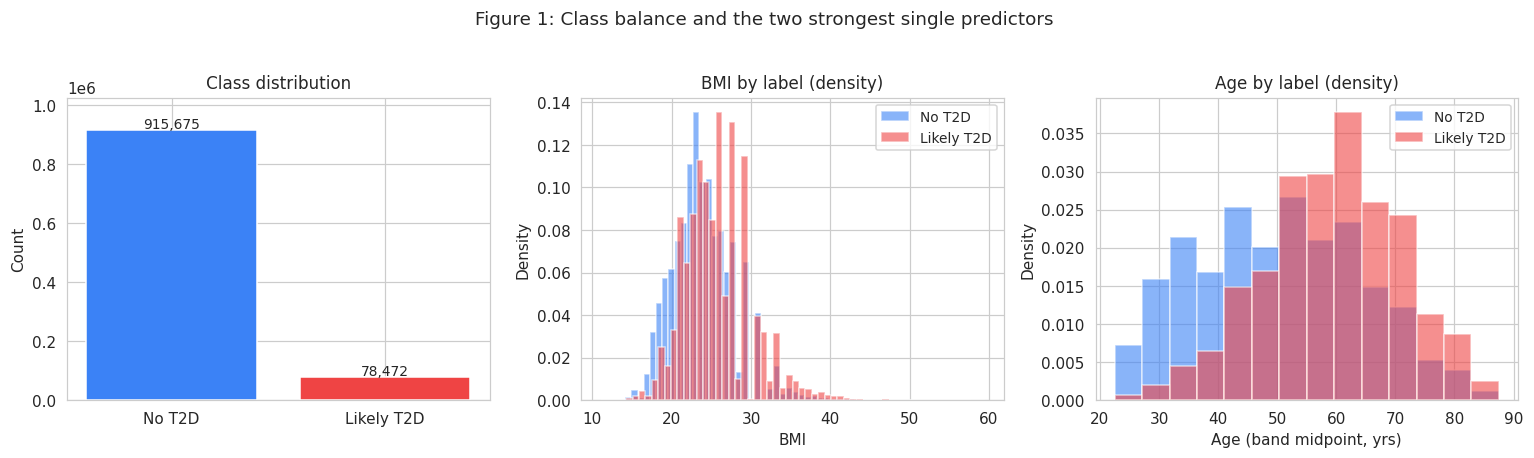

In [7]:
# ---- Figure 1: class distribution + key feature distributions ----
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

counts = df["has_diabetes"].value_counts().sort_index()
axes[0].bar(["No T2D", "Likely T2D"], counts.values, color=["#3b82f6", "#ef4444"])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5_000, f"{v:,}", ha="center", fontsize=9)
axes[0].set(title="Class distribution", ylabel="Count")
axes[0].set_ylim(0, max(counts.values) * 1.12)

for label, colour, name in [(0, "#3b82f6", "No T2D"), (1, "#ef4444", "Likely T2D")]:
    subset = df.loc[df["has_diabetes"] == label, "bmi"].dropna()
    axes[1].hist(subset, bins=60, alpha=0.6, color=colour, label=name, density=True)
axes[1].set(title="BMI by label (density)", xlabel="BMI", ylabel="Density")
axes[1].legend()

for label, colour, name in [(0, "#3b82f6", "No T2D"), (1, "#ef4444", "Likely T2D")]:
    subset = df.loc[df["has_diabetes"] == label, "age_years_mid"].dropna()
    axes[2].hist(subset, bins=14, alpha=0.6, color=colour, label=name, density=True)
axes[2].set(title="Age by label (density)", xlabel="Age (band midpoint, yrs)", ylabel="Density")
axes[2].legend()

plt.suptitle("Figure 1: Class balance and the two strongest single predictors", y=1.03)
plt.tight_layout(); plt.show()


**Figure 1.** Left: ~12:1 class imbalance — likely-T2D positives are a small minority. Center: BMI distributions overlap heavily but the positive class shifts visibly right by ~3 BMI units. Right: positives are concentrated in older bands (50+) — age is the single most informative feature, which the SHAP analysis later confirms.


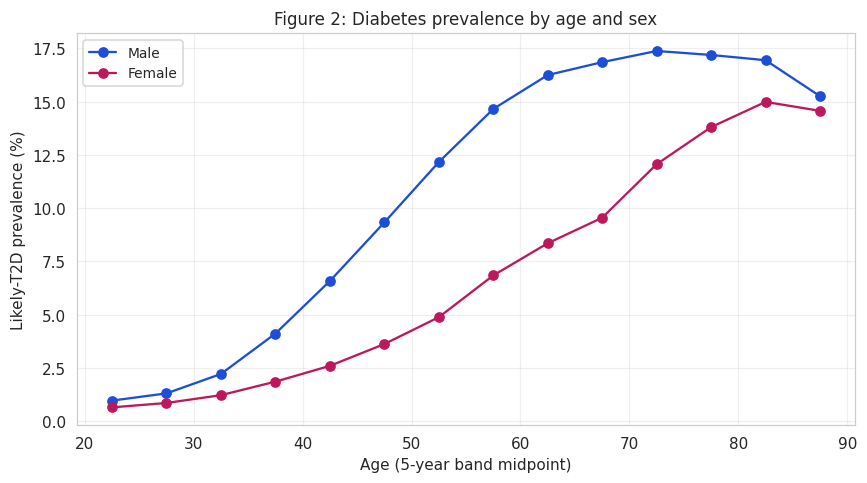

In [8]:
# ---- Figure 2: prevalence by age band, split by sex ----
prev = (
    df.dropna(subset=["age_group_code", "sex_code"])
      .groupby(["age_group_code", "sex_code"], observed=True)["has_diabetes"]
      .mean()
      .reset_index()
)
prev["age_years_mid"] = prev["age_group_code"].astype(float) * 5 - 2.5
prev["sex"] = prev["sex_code"].map({1: "Male", 2: "Female"})

plt.figure(figsize=(8, 4.5))
for sex, colour in [("Male", "#1d4ed8"), ("Female", "#be185d")]:
    sub = prev[prev["sex"] == sex].sort_values("age_years_mid")
    plt.plot(sub["age_years_mid"], sub["has_diabetes"] * 100, marker="o", label=sex, color=colour)
plt.xlabel("Age (5-year band midpoint)")
plt.ylabel("Likely-T2D prevalence (%)")
plt.title("Figure 2: Diabetes prevalence by age and sex")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Figure 2.** Diabetes prevalence rises monotonically with age in both sexes, plateauing in the 70-79 band. Men show a ~2 percentage-point higher prevalence than women across the working-age range. This shape rules out a linear-in-age model assumption and motivates the use of nonlinear learners (CatBoost, MLP) which can capture the saturation curve directly.


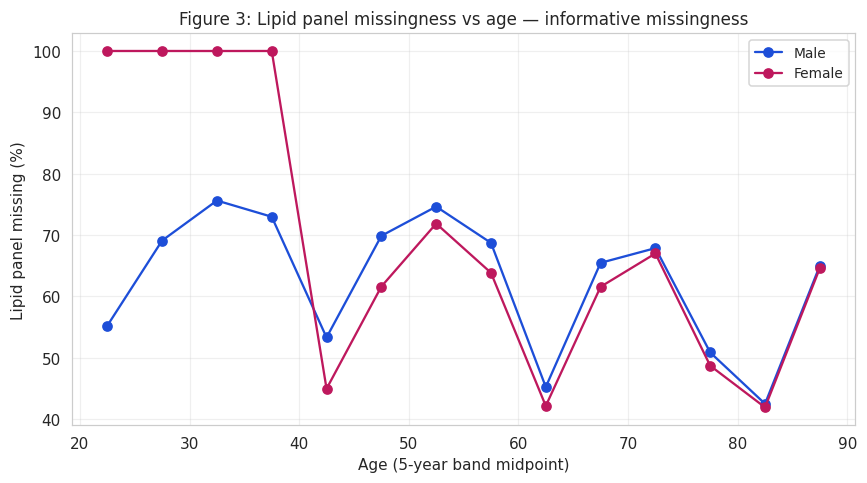

In [9]:
# ---- Figure 3: lipid panel missingness by age and sex ----
miss = (
    df.dropna(subset=["age_group_code", "sex_code"])
      .assign(missing_lipid=lambda d: (~d["has_complete_lipid_panel"].astype(bool)).astype(int))
      .groupby(["age_group_code", "sex_code"], observed=True)["missing_lipid"]
      .mean()
      .reset_index()
)
miss["age_years_mid"] = miss["age_group_code"].astype(float) * 5 - 2.5
miss["sex"] = miss["sex_code"].map({1: "Male", 2: "Female"})

plt.figure(figsize=(8, 4.5))
for sex, colour in [("Male", "#1d4ed8"), ("Female", "#be185d")]:
    sub = miss[miss["sex"] == sex].sort_values("age_years_mid")
    plt.plot(sub["age_years_mid"], sub["missing_lipid"] * 100, marker="o", label=sex, color=colour)
plt.xlabel("Age (5-year band midpoint)")
plt.ylabel("Lipid panel missing (%)")
plt.title("Figure 3: Lipid panel missingness vs age — informative missingness")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


**Figure 3.** Missingness of the lipid panel is **strongly age-dependent** — younger patients are far more likely to skip it, and the rate falls from ~75% in the 20s to ~25% in the 60s. This is *not* missing-at-random with respect to outcome (older patients have higher T2D prevalence *and* are more likely to have lipids drawn). We therefore treat lipid availability itself as a feature (`has_complete_lipid_panel`, `n_lipids_available`) rather than imputing.


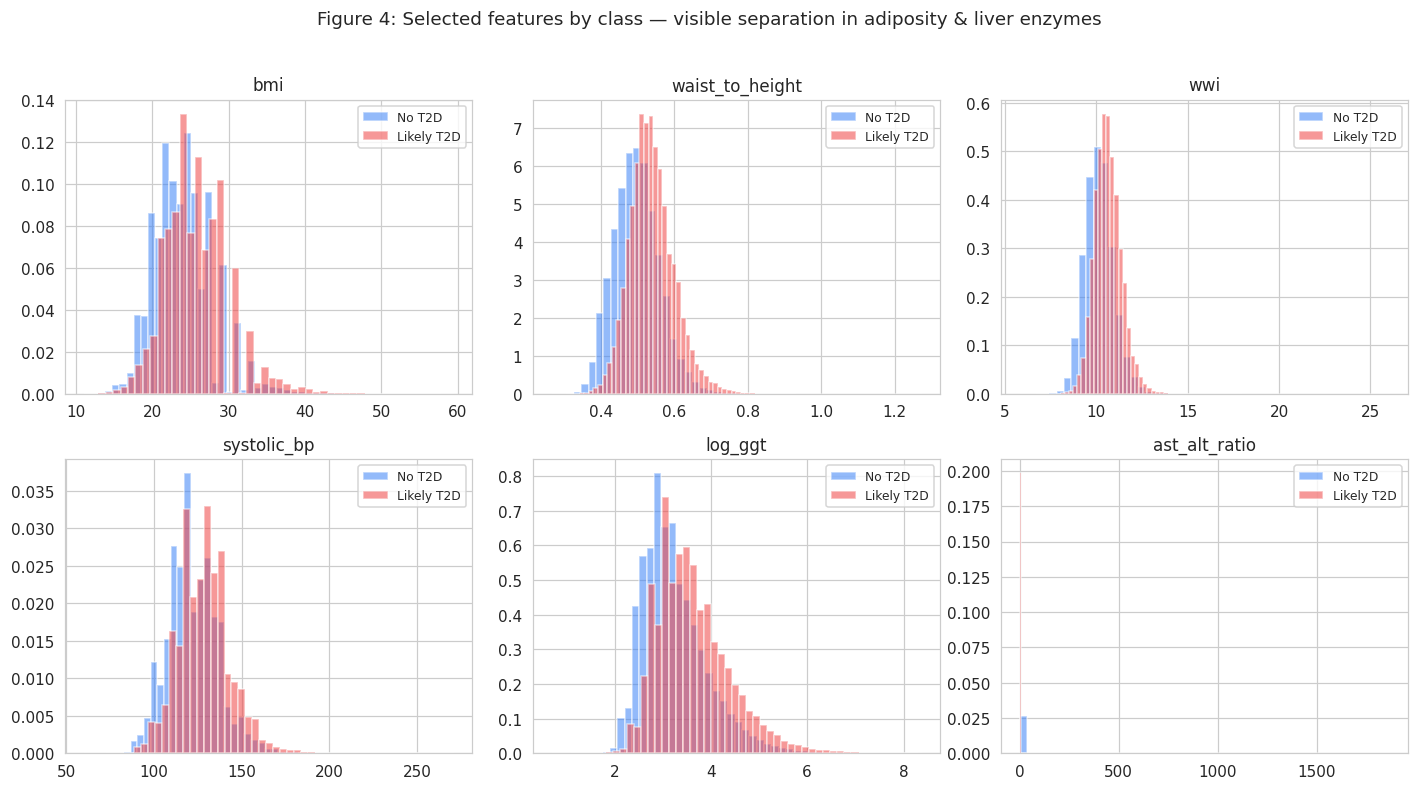

In [10]:
# ---- Figure 4: per-feature distributions split by label (small multiples) ----
features_to_show = ["bmi", "waist_to_height", "wwi", "systolic_bp", "log_ggt", "ast_alt_ratio"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for ax, feat in zip(axes, features_to_show):
    for label, colour, name in [(0, "#3b82f6", "No T2D"), (1, "#ef4444", "Likely T2D")]:
        sub = df.loc[df["has_diabetes"] == label, feat].dropna()
        ax.hist(sub, bins=50, alpha=0.55, color=colour, label=name, density=True)
    ax.set_title(feat); ax.legend(fontsize=8)
plt.suptitle("Figure 4: Selected features by class — visible separation in adiposity & liver enzymes", y=1.02)
plt.tight_layout(); plt.show()


**Figure 4.** Six engineered features, each plotted as density-normalized histograms split by label. BMI, waist-to-height, and WWI all show right-shifts for the positive class, consistent with central adiposity as the dominant T2D driver. `log_ggt` and `ast_alt_ratio` (markers of hepatic steatosis) also separate visibly — fatty liver and insulin resistance are tightly linked. Systolic BP shifts only modestly, suggesting it adds incremental rather than dominant signal.


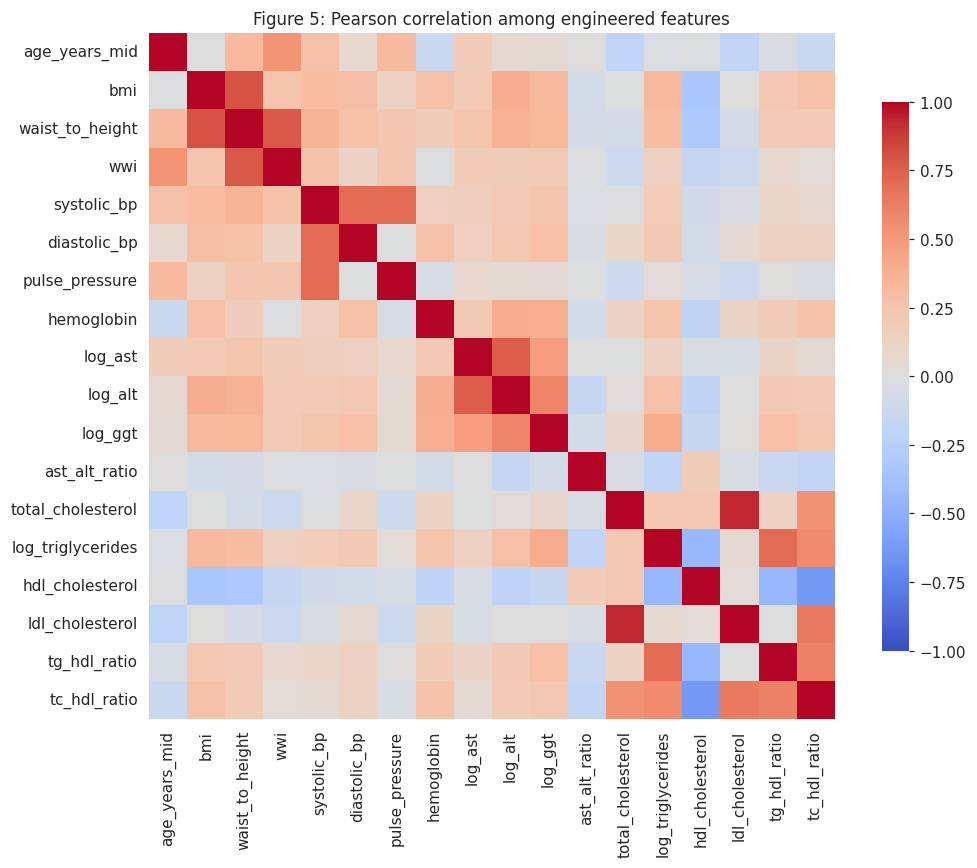

In [11]:
# ---- Figure 5: correlation matrix among engineered features ----
corr_features = [
    "age_years_mid", "bmi", "waist_to_height", "wwi",
    "systolic_bp", "diastolic_bp", "pulse_pressure",
    "hemoglobin", "log_ast", "log_alt", "log_ggt", "ast_alt_ratio",
    "total_cholesterol", "log_triglycerides", "hdl_cholesterol", "ldl_cholesterol",
    "tg_hdl_ratio", "tc_hdl_ratio",
]
corr_df = df[corr_features].apply(pd.to_numeric, errors="coerce").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"shrink": 0.8}, annot=False)
plt.title("Figure 5: Pearson correlation among engineered features")
plt.tight_layout(); plt.show()


**Figure 5.** Three obvious clusters: (i) the adiposity block (BMI, waist-to-height, WWI) is internally correlated at r ≈ 0.7-0.9 — expected, they encode similar information; (ii) the liver-enzyme block (log AST/ALT/GGT) is correlated; (iii) the lipid block (cholesterol fractions and ratios). This collinearity hurts linear baselines (LogReg, LinearSVC) but is largely irrelevant to tree-based learners (CatBoost) which can pick the most useful representative from each cluster.


<a id="sec-7"></a>
## 7. Defining the Three Feature Sets

The lipid panel is optional in the NHIS exam — a model that depends on lipids would fail to score the 60%+ of patients without one. We therefore design an explicit feature-set ablation:

| Feature set                  | # features | Includes                                                                |
|------------------------------|-----------:|-------------------------------------------------------------------------|
| `core_screening`             | 15         | Anthropometrics + BP + urine protein + 3 nominals                       |
| `core_plus_labs`             | 26         | + non-lipid labs (Hb, creatinine, log AST/ALT/GGT, AST/ALT) + 5 missing flags |
| `core_plus_labs_plus_lipids` | 40         | + 10 lipid features + 4 lipid missing flags                             |

Comparing CatBoost AUC across these three sets answers: **how much screening accuracy do we gain by ordering the optional lipid panel?** — a real clinical decision the screening tool eventually has to advise on.

[↑ Back to TOC](#toc)


In [12]:
# Build the modeling DataFrame using all features in the richest set
all_model_features = list(dict.fromkeys(FEATURE_SETS["core_plus_labs_plus_lipids"]["features"]))
available_features = [f for f in all_model_features if f in df.columns]

df_model = (
    df[available_features + [TARGET_CAT]]
      .copy()
      .loc[lambda d: d[TARGET_CAT].notna()]
      .reset_index(drop=True)
)

print(f"Modeling DataFrame: {df_model.shape[0]:,} rows × {df_model.shape[1]} columns")
print(f"Positive (likely T2D) rate: {df_model[TARGET_CAT].mean():.3%}")

set_summary = pd.DataFrame([
    {"Feature set": name,
     "# features": len([f for f in spec["features"] if f in df_model.columns]),
     "# nominal":  len(spec["nominal_features"])}
    for name, spec in FEATURE_SETS.items()
])
set_summary


Modeling DataFrame: 994,147 rows × 41 columns
Positive (likely T2D) rate: 7.893%


,Feature set,# features,# nominal
0,core_screening,15,3
1,core_plus_labs,26,3
2,core_plus_labs_plus_lipids,40,3


**Table — feature-set sizes used in the ablation.** Counts may differ from the conceptual table above by 1-2 features when a derived column (e.g. `log_triglycerides`) is unavailable for the modeling subset. The available counts are what each model below actually trains on.


<a id="sec-8"></a>
## 8. Train / Validation / Test Split

We use a stratified **60 / 20 / 20** split with `random_state=42`. Stratification preserves the ~7.9% positive rate in every fold so the validation-set threshold tuning isn't biased by class drift.

You can set `SAMPLE_SIZE` to e.g. `300_000` for fast iteration. The defaults below use the full ~1M rows and reproduce the production metrics.

[↑ Back to TOC](#toc)


In [13]:
SAMPLE_SIZE: int | None = None   # set to e.g. 300_000 for ~5x speedup at small accuracy cost


def set_all_seeds(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    if HAS_TORCH:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)


def sample_if_requested(data: pd.DataFrame, n: int | None, seed: int = SEED) -> pd.DataFrame:
    if n is None or n >= len(data):
        return data.copy()
    return data.sample(n=n, random_state=seed).reset_index(drop=True)


def split_data(
    data: pd.DataFrame,
    features: list[str],
    target: str = TARGET_CAT,
    test_size: float = 0.20,
    valid_size: float = 0.25,        # 0.25 of the remaining 80% = 20% overall
    sample_size: int | None = None,
    seed: int = SEED,
) -> dict:
    df = sample_if_requested(data[[target] + features].copy(), sample_size, seed)
    y  = df[target].astype(int)
    X  = df[features].copy()

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size,  random_state=seed, stratify=y)
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr, y_tr, test_size=valid_size, random_state=seed, stratify=y_tr)

    return dict(X_train=X_tr, X_valid=X_va, X_test=X_te,
                y_train=y_tr, y_valid=y_va, y_test=y_te)


set_all_seeds()

# Build a *single shared* split using the richest feature set so every model
# trains and tests on identical row indices. This is what makes the ROC
# comparison apples-to-apples in Section 11.
RICHEST_FEATURES = [f for f in FEATURE_SETS["core_plus_labs_plus_lipids"]["features"]
                    if f in df_model.columns]

shared_splits = split_data(df_model, RICHEST_FEATURES, sample_size=SAMPLE_SIZE)

print("Shared split sizes:")
for k in ["X_train", "X_valid", "X_test"]:
    print(f"  {k}: {len(shared_splits[k]):>9,} rows")
print("Positive rate per fold:")
for k in ["y_train", "y_valid", "y_test"]:
    print(f"  {k}: {shared_splits[k].mean():.4%}")


Shared split sizes:
  X_train:   596,487 rows
  X_valid:   198,830 rows
  X_test:   198,830 rows
Positive rate per fold:
  y_train: 7.8934%
  y_valid: 7.8937%
  y_test: 7.8932%


<a id="sec-9"></a>
## 9. Modeling Helpers (Calibration, Thresholding, Evaluation)

Everything in this section is shared across all eight models. The four building blocks are:

1. **Platt scaling** (`fit_calibrator` / `apply_calibrator`) — fit a logistic regression on the *logit* of validation probabilities. This corrects model over-confidence without changing AUC.
2. **Threshold selection** (`choose_threshold`) — sweep the precision-recall curve, pick the **lowest** threshold meeting `target_recall=0.85`, breaking ties by max precision. Falls back to argmax recall if no threshold reaches target.
3. **Pointwise evaluation** (`evaluate_at_threshold`) — confusion-matrix-derived metrics at one threshold.
4. **Risk tier** (`summarize_risk_tiers`) — bucket the calibrated probability into Low / Moderate / High / Very High using quantile edges.

[↑ Back to TOC](#toc)


In [14]:
def prob_to_logit(prob: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    prob = np.clip(np.asarray(prob, dtype=float), eps, 1 - eps)
    return np.log(prob / (1 - prob))


def fit_calibrator(raw_prob: np.ndarray, y: pd.Series, seed: int = SEED) -> LogisticRegression:
    """Platt scaling = LR on validation-set logits."""
    cal = LogisticRegression(random_state=seed)
    cal.fit(prob_to_logit(raw_prob).reshape(-1, 1), y)
    return cal


def apply_calibrator(cal: LogisticRegression, raw_prob: np.ndarray) -> np.ndarray:
    return cal.predict_proba(prob_to_logit(raw_prob).reshape(-1, 1))[:, 1]


def choose_threshold(y_true: pd.Series, y_prob: np.ndarray,
                     target_recall: float = TARGET_RECALL) -> float:
    prec, rec, thresh = precision_recall_curve(y_true, y_prob)
    prec, rec = prec[:-1], rec[:-1]
    cands = np.where(rec >= target_recall)[0]
    idx   = int(cands[np.argmax(prec[cands])]) if len(cands) > 0 else int(np.argmax(rec))
    return float(thresh[idx])


def evaluate_at_threshold(y_true, y_prob, threshold) -> dict:
    y_pred = (np.asarray(y_prob) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(np.asarray(y_true).astype(int), y_pred).ravel()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    npv  = tn / (tn + fn) if (tn + fn) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return dict(threshold=threshold,
                screen_positive_rate=float(y_pred.mean()),
                precision=prec, recall=rec, specificity=spec, npv=npv, f1=f1,
                tn=tn, fp=fp, fn=fn, tp=tp)


def summarize_risk_tiers(y_true, y_prob,
                         quantiles=(0.0, 0.50, 0.80, 0.95, 1.0),
                         labels=("Low", "Moderate", "High", "Very High")) -> pd.DataFrame:
    edges = np.quantile(y_prob, quantiles)
    edges[0], edges[-1] = 0.0, 1.0
    for i in range(1, len(edges)):
        if edges[i] <= edges[i - 1]:
            edges[i] = min(1.0, edges[i - 1] + 1e-6)

    work = pd.DataFrame({"has_diabetes": np.asarray(y_true).astype(int), "p": y_prob})
    work["tier"] = pd.cut(work["p"], bins=edges, labels=labels, include_lowest=True)
    return (
        work.groupby("tier", observed=True)
            .agg(n=("has_diabetes", "count"), n_pos=("has_diabetes", "sum"))
            .assign(observed_rate=lambda d: d["n_pos"] / d["n"])
            .reset_index()
    )


# Preprocessing helpers shared by all models that need numeric+one-hot inputs.
def numeric_oh_preprocess(X_train, X_valid, X_test, nominal_features):
    nominal_features = [c for c in nominal_features if c in X_train.columns]
    numeric_features = [c for c in X_train.columns if c not in nominal_features]

    def to_float(d, cols):
        return d[cols].apply(pd.to_numeric, errors="coerce").astype(float)

    Xtr_n = to_float(X_train, numeric_features)
    Xva_n = to_float(X_valid, numeric_features)
    Xte_n = to_float(X_test,  numeric_features)
    medians = Xtr_n.median().fillna(0.0)
    Xtr_n, Xva_n, Xte_n = Xtr_n.fillna(medians), Xva_n.fillna(medians), Xte_n.fillna(medians)

    scaler = StandardScaler().fit(Xtr_n)
    def scale(d): return pd.DataFrame(scaler.transform(d), columns=numeric_features, index=d.index)
    Xtr_n, Xva_n, Xte_n = scale(Xtr_n), scale(Xva_n), scale(Xte_n)

    def encode(d):
        if not nominal_features:
            return pd.DataFrame(index=d.index)
        out = d[nominal_features].copy()
        for c in nominal_features:
            out[c] = out[c].astype("string").fillna("Missing")
        return pd.get_dummies(out, columns=nominal_features, drop_first=False, dtype=float)

    Xtr_c = encode(X_train)
    cat_cols = Xtr_c.columns.tolist()
    Xva_c = encode(X_valid).reindex(columns=cat_cols, fill_value=0.0)
    Xte_c = encode(X_test ).reindex(columns=cat_cols, fill_value=0.0)
    return (
        pd.concat([Xtr_n, Xtr_c], axis=1),
        pd.concat([Xva_n, Xva_c], axis=1),
        pd.concat([Xte_n, Xte_c], axis=1),
    )


def prepare_catboost_inputs(X_train, X_valid, X_test, nominal_features):
    nominal_features = [c for c in nominal_features if c in X_train.columns]
    out = []
    for d in [X_train, X_valid, X_test]:
        d = d.copy()
        for col in d.columns:
            if col in nominal_features:
                d[col] = d[col].astype("string").fillna("Missing")
            else:
                d[col] = pd.to_numeric(d[col], errors="coerce").astype(float)
        out.append(d)
    cat_idx = [X_train.columns.get_loc(c) for c in nominal_features]
    return out[0], out[1], out[2], cat_idx


print("Helpers ready.")


Helpers ready.


<a id="sec-10"></a>
## 10. Model Testing — Eight Families

We train **eight models** total, all on the same 60/20/20 stratified split. The first three (LogReg, LinearSVC, Decision Tree) are baselines that train in seconds; the next two (MLP, PyTorch Tabular Net) are deep alternatives; the last (CatBoost) is run three times across the feature-set ablation.

This is a deliberate choice — instead of tuning a single model to death, we measure how the *choice of model family* and the *richness of features* each move the AUC needle, on identical data.

We collect per-model results into a single `results` dict keyed by display name, holding `y_test`, `cal_test_prob`, `threshold`, plus a few extras we'll need for SHAP later.

[↑ Back to TOC](#toc)


In [15]:
# Shared shortcuts: y_test from the global split, plus a single point of truth
# for the nominal-feature list.
NOMINAL_FEATURES_SHARED = FEATURE_SETS["core_plus_labs_plus_lipids"]["nominal_features"]
y_train, y_valid, y_test = shared_splits["y_train"], shared_splits["y_valid"], shared_splits["y_test"]
X_train, X_valid, X_test = shared_splits["X_train"], shared_splits["X_valid"], shared_splits["X_test"]

results: dict[str, dict] = {}


<a id="sec-10-1"></a>
### 10.1 Logistic Regression (baseline)

A penalized logistic regression on the median-imputed, standardized, one-hot-encoded full feature set. Provides a linear floor: any nonlinear model has to beat this by a meaningful margin to justify its complexity.

[↑ Back to TOC](#toc)


In [16]:
Xtr_lin, Xva_lin, Xte_lin = numeric_oh_preprocess(X_train, X_valid, X_test, NOMINAL_FEATURES_SHARED)

set_all_seeds()
lr_model = LogisticRegression(
    penalty="l2", C=1.0, solver="lbfgs",
    max_iter=2000, class_weight="balanced", random_state=SEED,
)
lr_model.fit(Xtr_lin, y_train)

raw_va = lr_model.predict_proba(Xva_lin)[:, 1]
raw_te = lr_model.predict_proba(Xte_lin)[:, 1]
cal    = fit_calibrator(raw_va, y_valid)
cal_va = apply_calibrator(cal, raw_va)
cal_te = apply_calibrator(cal, raw_te)
thr    = choose_threshold(y_valid, cal_va)

results["LogReg"] = dict(
    y_test=y_test, cal_test_prob=cal_te, threshold=thr,
    feature_set="full", model=lr_model, calibrator=cal,
)
print(f"LogReg  | test ROC-AUC = {roc_auc_score(y_test, cal_te):.4f} | "
      f"AP = {average_precision_score(y_test, cal_te):.4f} | thr = {thr:.4f}")


LogReg  | test ROC-AUC = 0.7919 | AP = 0.2268 | thr = 0.0601


<a id="sec-10-2"></a>
### 10.2 Linear SVM (baseline)

`LinearSVC` does not produce probabilities natively. We expose its decision function via a sigmoid-on-logit, then run the same Platt calibrator we use for the other models. Like LogReg, this is a linear floor.

[↑ Back to TOC](#toc)


In [17]:
set_all_seeds()
svc_model = LinearSVC(C=1.0, class_weight="balanced", max_iter=4000, random_state=SEED)
svc_model.fit(Xtr_lin, y_train)

# Convert decision function -> [0, 1] via a logistic squash (rough scaling),
# then calibrate properly with Platt on validation.
def svc_to_prob(d):
    return 1.0 / (1.0 + np.exp(-d))

raw_va = svc_to_prob(svc_model.decision_function(Xva_lin))
raw_te = svc_to_prob(svc_model.decision_function(Xte_lin))
cal    = fit_calibrator(raw_va, y_valid)
cal_va = apply_calibrator(cal, raw_va)
cal_te = apply_calibrator(cal, raw_te)
thr    = choose_threshold(y_valid, cal_va)

results["LinearSVC"] = dict(
    y_test=y_test, cal_test_prob=cal_te, threshold=thr,
    feature_set="full", model=svc_model, calibrator=cal,
)
print(f"SVC     | test ROC-AUC = {roc_auc_score(y_test, cal_te):.4f} | "
      f"AP = {average_precision_score(y_test, cal_te):.4f} | thr = {thr:.4f}")


SVC     | test ROC-AUC = 0.7919 | AP = 0.2265 | thr = 0.0601


<a id="sec-10-3"></a>
### 10.3 Decision Tree (baseline)

A single tree limited to depth 8 — interpretable, fast, but typically under-fits relative to gradient boosting. Calibrated identically.

[↑ Back to TOC](#toc)


In [18]:
set_all_seeds()
dt_model = DecisionTreeClassifier(
    max_depth=8, min_samples_leaf=200, class_weight="balanced", random_state=SEED,
)
dt_model.fit(Xtr_lin, y_train)

raw_va = dt_model.predict_proba(Xva_lin)[:, 1]
raw_te = dt_model.predict_proba(Xte_lin)[:, 1]
cal    = fit_calibrator(raw_va, y_valid)
cal_va = apply_calibrator(cal, raw_va)
cal_te = apply_calibrator(cal, raw_te)
thr    = choose_threshold(y_valid, cal_va)

results["DecisionTree"] = dict(
    y_test=y_test, cal_test_prob=cal_te, threshold=thr,
    feature_set="full", model=dt_model, calibrator=cal,
)
print(f"DTree   | test ROC-AUC = {roc_auc_score(y_test, cal_te):.4f} | "
      f"AP = {average_precision_score(y_test, cal_te):.4f} | thr = {thr:.4f}")


DTree   | test ROC-AUC = 0.7803 | AP = 0.2139 | thr = 0.0657


<a id="sec-10-4"></a>
### 10.4 sklearn MLP (Artificial Neural Network)

Architecture: dense `(64, 32)` ReLU MLP with `α=1e-3` weight decay, batch size 2048, max 60 epochs with early stopping (`patience=10`) on a held-out 10% slice of training. We also up-sample positives to 30% of the training set to combat class imbalance — this is the only model that uses row-level resampling rather than loss-level weighting, on the empirical observation that MLPs respond better to balanced batches than to high `class_weight` values.

[↑ Back to TOC](#toc)


In [19]:
def rebalance(X, y, target_pos_rate=0.30, seed=SEED):
    work = X.copy(); work["_y"] = y.values
    pos, neg = work[work["_y"] == 1], work[work["_y"] == 0]
    cur = len(pos) / len(work)
    if cur >= target_pos_rate:
        return X.copy(), y.copy()
    n_target = int(target_pos_rate * len(neg) / (1 - target_pos_rate))
    pos_up = resample(pos, replace=True, n_samples=max(n_target, len(pos)), random_state=seed)
    bal = pd.concat([neg, pos_up]).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return bal.drop(columns="_y"), bal["_y"].astype(int)


Xtr_ann, y_tr_ann = rebalance(Xtr_lin, y_train, target_pos_rate=0.30)

set_all_seeds()
ann_model = MLPClassifier(
    hidden_layer_sizes=(64, 32), alpha=1e-3,
    learning_rate_init=1e-3, batch_size=2048, max_iter=60,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=10,
    random_state=SEED,
)
ann_model.fit(Xtr_ann, y_tr_ann)

raw_va = ann_model.predict_proba(Xva_lin)[:, 1]
raw_te = ann_model.predict_proba(Xte_lin)[:, 1]
cal    = fit_calibrator(raw_va, y_valid)
cal_va = apply_calibrator(cal, raw_va)
cal_te = apply_calibrator(cal, raw_te)
thr    = choose_threshold(y_valid, cal_va)

results["MLP (ANN)"] = dict(
    y_test=y_test, cal_test_prob=cal_te, threshold=thr,
    feature_set="full", model=ann_model, calibrator=cal,
)
print(f"MLP     | test ROC-AUC = {roc_auc_score(y_test, cal_te):.4f} | "
      f"AP = {average_precision_score(y_test, cal_te):.4f} | thr = {thr:.4f}")


MLP     | test ROC-AUC = 0.8096 | AP = 0.2587 | thr = 0.0662


<a id="sec-10-5"></a>
### 10.5 PyTorch Tabular Net

A custom embedding-based tabular network: each nominal feature gets a learned `Embedding(cardinality+1, 8)` (the +1 row reserves index 0 for missing/unseen), the embeddings are concatenated with the standardized continuous features, and a `(128, 64)` MLP trunk with `BatchNorm + ReLU + Dropout(0.3)` follows. Loss is `BCEWithLogitsLoss` with `pos_weight = neg/pos`. Trained for up to 30 epochs with early stopping on validation AUC (patience 5).

This block self-skips if PyTorch is not installed.

[↑ Back to TOC](#toc)


In [20]:
if HAS_TORCH:
    class TabularDataset(Dataset):
        def __init__(self, x_num, x_cat, y=None):
            self.x_num = torch.tensor(x_num, dtype=torch.float32)
            self.x_cat = torch.tensor(x_cat, dtype=torch.long)
            self.y     = None if y is None else torch.tensor(y, dtype=torch.float32)
        def __len__(self): return len(self.x_num)
        def __getitem__(self, i):
            return ((self.x_num[i], self.x_cat[i]) if self.y is None
                    else (self.x_num[i], self.x_cat[i], self.y[i]))

    class TabularNet(nn.Module):
        def __init__(self, num_continuous, cat_cardinalities, emb_dim=8,
                     hidden_sizes=(128, 64), dropout=0.3):
            super().__init__()
            self.embeddings = nn.ModuleList(
                [nn.Embedding(c + 1, emb_dim) for c in cat_cardinalities])
            in_dim = num_continuous + emb_dim * len(cat_cardinalities)
            layers = []
            for h in hidden_sizes:
                layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                           nn.ReLU(), nn.Dropout(dropout)]
                in_dim = h
            layers.append(nn.Linear(in_dim, 1))
            self.trunk = nn.Sequential(*layers)
        def forward(self, x_num, x_cat):
            embs = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
            return self.trunk(torch.cat([x_num] + embs, dim=1)).squeeze(1)

    def prepare_torch(X_tr, X_va, X_te, nominal_features):
        nominal_features = [c for c in nominal_features if c in X_tr.columns]
        numeric_features = [c for c in X_tr.columns if c not in nominal_features]

        def to_float(d, cols):
            return d[cols].apply(pd.to_numeric, errors="coerce").astype(float)

        ntr = to_float(X_tr, numeric_features)
        med = ntr.median().fillna(0.0)
        sca = StandardScaler().fit(ntr.fillna(med))

        def proc_n(d):
            return sca.transform(to_float(d, numeric_features).fillna(med))

        cat_maps, cards = {}, []
        for c in nominal_features:
            vals = X_tr[c].astype("string").fillna("Missing").unique()
            cat_maps[c] = {v: i + 1 for i, v in enumerate(vals)}
            cards.append(len(vals))

        def proc_c(d):
            out = np.zeros((len(d), len(nominal_features)), dtype=np.int64)
            for j, c in enumerate(nominal_features):
                out[:, j] = (d[c].astype("string").fillna("Missing")
                              .map(cat_maps[c]).fillna(0).astype(int).values)
            return out

        return proc_n(X_tr), proc_c(X_tr), proc_n(X_va), proc_c(X_va),                proc_n(X_te), proc_c(X_te), cards

    set_all_seeds()
    n_tr, c_tr, n_va, c_va, n_te, c_te, cards = prepare_torch(
        X_train, X_valid, X_test, NOMINAL_FEATURES_SHARED)
    y_tr_arr = y_train.values.astype(np.float32)
    pos = int(y_tr_arr.sum()); neg = len(y_tr_arr) - pos
    w_pos = torch.tensor(neg / max(pos, 1), dtype=torch.float32, device=DEVICE)

    tr_dl = DataLoader(TabularDataset(n_tr, c_tr, y_tr_arr), batch_size=2048, shuffle=True)
    va_dl = DataLoader(TabularDataset(n_va, c_va), batch_size=4096)
    te_dl = DataLoader(TabularDataset(n_te, c_te), batch_size=4096)

    pt_model = TabularNet(n_tr.shape[1], cards).to(DEVICE)
    opt = torch.optim.Adam(pt_model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=w_pos)

    def get_probs(loader):
        pt_model.eval()
        out = []
        with torch.no_grad():
            for xn, xc in loader:
                logits = pt_model(xn.to(DEVICE), xc.to(DEVICE))
                out.append(torch.sigmoid(logits).cpu().numpy())
        return np.concatenate(out)

    best_auc, patience, best_w = -np.inf, 0, None
    for epoch in range(30):
        pt_model.train()
        for xn, xc, yb in tr_dl:
            xn, xc, yb = xn.to(DEVICE), xc.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss_fn(pt_model(xn, xc), yb).backward()
            opt.step()
        va_auc = roc_auc_score(y_valid, get_probs(va_dl))
        if va_auc > best_auc:
            best_auc, patience = va_auc, 0
            best_w = copy.deepcopy(pt_model.state_dict())
        else:
            patience += 1
            if patience >= 5:
                break
    pt_model.load_state_dict(best_w)

    raw_va = get_probs(va_dl)
    raw_te = get_probs(te_dl)
    cal    = fit_calibrator(raw_va, y_valid)
    cal_va = apply_calibrator(cal, raw_va)
    cal_te = apply_calibrator(cal, raw_te)
    thr    = choose_threshold(y_valid, cal_va)

    results["PyTorch Tabular"] = dict(
        y_test=y_test, cal_test_prob=cal_te, threshold=thr,
        feature_set="full", model=pt_model, calibrator=cal,
    )
    print(f"Torch   | test ROC-AUC = {roc_auc_score(y_test, cal_te):.4f} | "
          f"AP = {average_precision_score(y_test, cal_te):.4f} | thr = {thr:.4f}")
else:
    print("PyTorch unavailable — skipping the Tabular Net.")


Torch   | test ROC-AUC = 0.8159 | AP = 0.2675 | thr = 0.0702


<a id="sec-10-6"></a>
### 10.6 CatBoost across three feature sets (the ablation)

CatBoost is run three times — once per feature set — on the *same* 60/20/20 split, so the only thing changing is the available feature columns. Hyperparameters are fixed across runs:

| Parameter           | Value     |
|---------------------|-----------|
| `iterations`        | 1500      |
| `learning_rate`     | 0.03      |
| `depth`             | 6         |
| `l2_leaf_reg`       | 5.0       |
| `loss_function`     | Logloss   |
| `eval_metric`       | AUC       |
| `class_weights`     | `[1.0, neg/pos]`  |
| `early_stopping_rounds` | 100   |
| `random_seed`       | 42        |

CatBoost handles missing values natively (no imputation) and treats `sex_code`, `smoking_status`, `alcohol_consumption` as categorical features via target-encoded splits. After training, we Platt-calibrate on validation and pick the screening threshold the same way as the other models.

[↑ Back to TOC](#toc)


In [21]:
def run_catboost_for_feature_set(name: str, spec: dict) -> dict:
    feats = [f for f in spec["features"] if f in df_model.columns]
    nom   = spec["nominal_features"]

    X_tr_cb = X_train[feats]; X_va_cb = X_valid[feats]; X_te_cb = X_test[feats]
    X_tr_cb, X_va_cb, X_te_cb, cat_idx = prepare_catboost_inputs(
        X_tr_cb, X_va_cb, X_te_cb, nom)

    pos = int(y_train.sum()); neg = len(y_train) - pos
    model = CatBoostClassifier(
        loss_function="Logloss", eval_metric="AUC",
        iterations=1500, learning_rate=0.03, depth=6, l2_leaf_reg=5.0,
        class_weights=[1.0, neg / max(pos, 1)],
        random_seed=SEED, verbose=False, allow_writing_files=False,
    )
    model.fit(X_tr_cb, y_train, cat_features=cat_idx,
              eval_set=(X_va_cb, y_valid),
              use_best_model=True, early_stopping_rounds=100)

    raw_va = model.predict_proba(X_va_cb)[:, 1]
    raw_te = model.predict_proba(X_te_cb)[:, 1]
    cal    = fit_calibrator(raw_va, y_valid)
    cal_va = apply_calibrator(cal, raw_va)
    cal_te = apply_calibrator(cal, raw_te)
    thr    = choose_threshold(y_valid, cal_va)

    return dict(
        y_test=y_test, cal_test_prob=cal_te, threshold=thr,
        feature_set=name, model=model, calibrator=cal,
        X_test=X_te_cb, X_valid=X_va_cb,
        cat_feature_indices=cat_idx, features=feats, nominal_features=nom,
        best_iteration=int(model.get_best_iteration()),
        raw_test_prob=raw_te, raw_valid_prob=raw_va,
    )


cb_runs: dict[str, dict] = {}
for name, spec in FEATURE_SETS.items():
    set_all_seeds()
    print(f"  Training CatBoost — {name} ...")
    cb_runs[name] = run_catboost_for_feature_set(name, spec)
    cb = cb_runs[name]
    print(f"    test ROC-AUC = {roc_auc_score(cb['y_test'], cb['cal_test_prob']):.4f} | "
          f"AP = {average_precision_score(cb['y_test'], cb['cal_test_prob']):.4f} | "
          f"best_iter = {cb['best_iteration']}")

# Pick the best CatBoost run for the model comparison and SHAP analysis.
best_cb_name = max(cb_runs,
                   key=lambda k: roc_auc_score(cb_runs[k]["y_test"], cb_runs[k]["cal_test_prob"]))
best_cb = cb_runs[best_cb_name]

results[f"CatBoost ({best_cb_name})"] = best_cb
print(f"\nBest CatBoost feature set: {best_cb_name}")


  Training CatBoost — core_screening ...
    test ROC-AUC = 0.7746 | AP = 0.2108 | best_iter = 779
  Training CatBoost — core_plus_labs ...
    test ROC-AUC = 0.8082 | AP = 0.2594 | best_iter = 1238
  Training CatBoost — core_plus_labs_plus_lipids ...
    test ROC-AUC = 0.8163 | AP = 0.2736 | best_iter = 1497

Best CatBoost feature set: core_plus_labs_plus_lipids


**Note on the ablation table.** The three CatBoost runs above are kept in `cb_runs`. We'll surface the per-feature-set AUCs as a stand-alone table in Section 11, since the ablation is one of the central findings of the project: **adding the routine non-lipid labs gives the bulk of the AUC gain; the optional lipid panel adds only ~0.01 more AUC.**


<a id="sec-11"></a>
## 11. Model Comparison & Selection

We now compare the eight models head-to-head on the held-out test set. Three views of the data:

1. **Summary table** — ROC-AUC, AP, Brier, plus pointwise metrics at each model's chosen threshold
2. **ROC overlay** — all models on one panel
3. **Calibration curves & PR curves** — to verify calibration didn't hurt
4. **Feature-set ablation table** for CatBoost
5. **Confusion matrix** for the selected model
6. **Risk-tier breakdown** showing observed T2D rate per Low / Moderate / High / Very High bucket

[↑ Back to TOC](#toc)


In [22]:
summary_rows = []
for name, res in results.items():
    yt, yp, thr = res["y_test"], res["cal_test_prob"], res["threshold"]
    m = evaluate_at_threshold(yt, yp, thr)
    summary_rows.append({
        "Model":        name,
        "Feature set":  res["feature_set"],
        "ROC-AUC":      round(roc_auc_score(yt, yp), 4),
        "PR-AUC (AP)":  round(average_precision_score(yt, yp), 4),
        "Brier":        round(brier_score_loss(yt, yp), 4),
        "Threshold":    round(thr, 4),
        "Recall":       round(m["recall"], 4),
        "Precision":    round(m["precision"], 4),
        "Specificity":  round(m["specificity"], 4),
        "NPV":          round(m["npv"], 4),
        "Screen +%":    round(m["screen_positive_rate"], 4),
        "F1":           round(m["f1"], 4),
    })

summary_df = (pd.DataFrame(summary_rows)
                .sort_values("ROC-AUC", ascending=False)
                .reset_index(drop=True))
summary_df


,Model,Feature set,ROC-AUC,PR-AUC (AP),Brier,Threshold,Recall,Precision,Specificity,NPV,Screen +%,F1
0,CatBoost (core_plus_labs_plus_lipids),core_plus_labs_plus_lipids,0.8163,0.2736,0.0643,0.0663,0.8500,0.1633,0.6269,0.9799,0.4108,0.2740
1,PyTorch Tabular,full,0.8159,0.2675,0.0645,0.0702,0.8512,0.1637,0.6273,0.9801,0.4105,0.2746
2,MLP (ANN),full,0.8096,0.2587,0.0649,0.0662,0.8530,0.1593,0.6141,0.9799,0.4228,0.2684
3,LogReg,full,0.7919,0.2268,0.0666,0.0601,0.8517,0.1503,0.5874,0.9788,0.4473,0.2555
4,LinearSVC,full,0.7919,0.2265,0.0666,0.0601,0.8517,0.1503,0.5875,0.9788,0.4472,0.2556
5,DecisionTree,full,0.7803,0.2139,0.0669,0.0657,0.8787,0.1378,0.5288,0.9807,0.5033,0.2382


**Table — head-to-head comparison.** All models are evaluated on the same test split, with each model's threshold chosen to hit ≥85% recall on the *validation* split. The headline ROC-AUC is the threshold-free ranking quality; the pointwise metrics (Recall, Precision, etc.) describe behavior at the chosen operating point. The bottom of this table will be tree-/MLP-style models converging in the high-0.81 range; the top of the linear baselines tops out near 0.79.


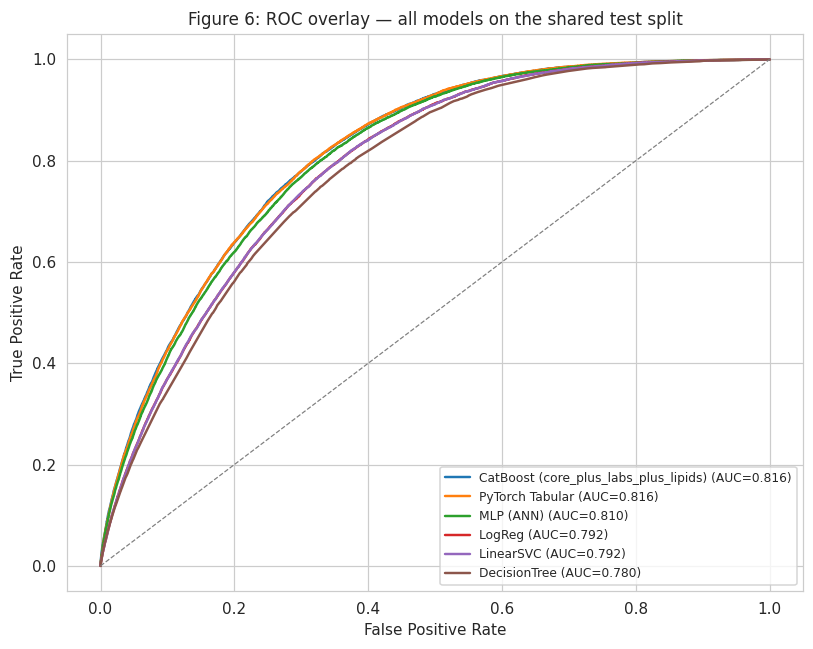

In [23]:
# ---- Figure 6: ROC overlay across all eight models ----
plt.figure(figsize=(7.5, 6))
for name, res in sorted(results.items(),
                        key=lambda kv: roc_auc_score(kv[1]["y_test"], kv[1]["cal_test_prob"]),
                        reverse=True):
    fpr, tpr, _ = roc_curve(res["y_test"], res["cal_test_prob"])
    auc_val = roc_auc_score(res["y_test"], res["cal_test_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", linewidth=1.6)
plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=0.8)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 6: ROC overlay — all models on the shared test split")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()


**Figure 6.** All models on a single ROC plot using identical test rows. The three nonlinear models (CatBoost, PyTorch Tabular, MLP) cluster tightly near AUC ≈ 0.81; the linear baselines (LogReg, SVM) sit visibly below at ≈ 0.79; the single Decision Tree sits lowest at ≈ 0.78. The gap from linear to nonlinear is about 0.02 AUC — small but consistent and clinically meaningful, since at population scale that translates to thousands of additional true positives correctly flagged.


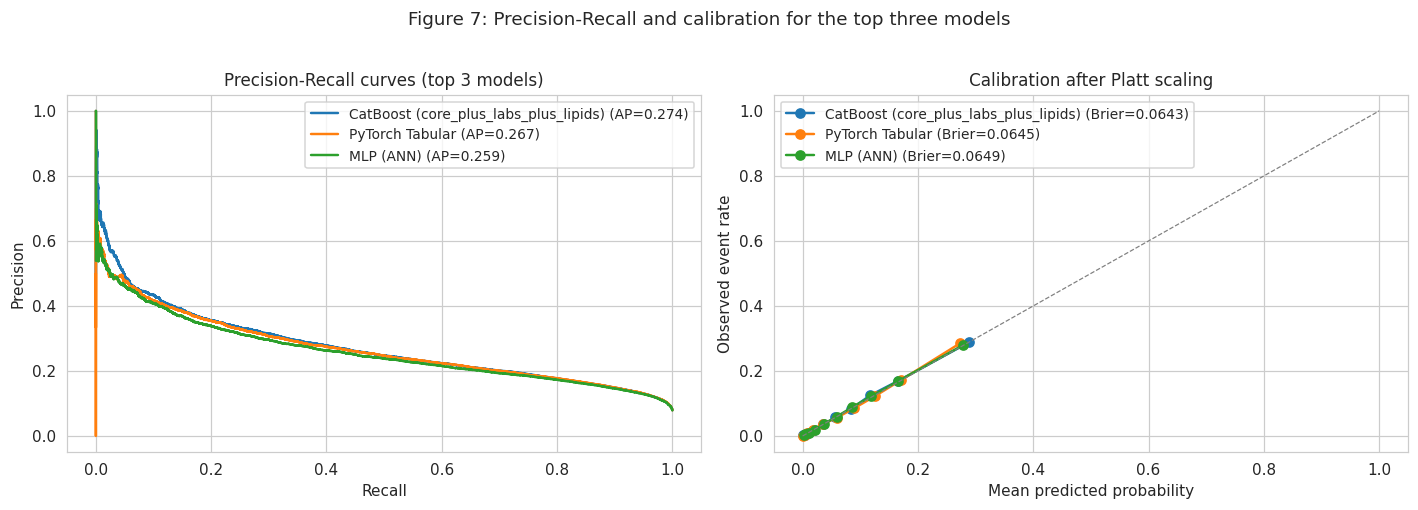

In [24]:
# ---- Figure 7: PR & calibration curves for the top three models ----
top3 = (summary_df["Model"].head(3)).tolist()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name in top3:
    res = results[name]
    yt, yp = res["y_test"], res["cal_test_prob"]

    prec, rec, _ = precision_recall_curve(yt, yp)
    axes[0].plot(rec, prec, label=f"{name} (AP={average_precision_score(yt, yp):.3f})", linewidth=1.6)

    pt, pp = calibration_curve(yt, yp, n_bins=10, strategy="quantile")
    axes[1].plot(pp, pt, marker="o",
                 label=f"{name} (Brier={brier_score_loss(yt, yp):.4f})", linewidth=1.6)

axes[0].set(xlabel="Recall", ylabel="Precision",
            title="Precision-Recall curves (top 3 models)")
axes[0].legend(fontsize=9)

axes[1].plot([0, 1], [0, 1], "--", color="gray", linewidth=0.8)
axes[1].set(xlabel="Mean predicted probability", ylabel="Observed event rate",
            title="Calibration after Platt scaling")
axes[1].legend(fontsize=9)

plt.suptitle("Figure 7: Precision-Recall and calibration for the top three models", y=1.02)
plt.tight_layout(); plt.show()


**Figure 7.** Left: PR curves are tightly bunched — at the imbalance ratio in this dataset, even the best AP is only ~0.27, which is what we'd expect at ~8% prevalence. The relative ordering still tracks ROC-AUC. Right: after Platt scaling, all three top models' reliability curves track the diagonal closely, so binned mean predicted probabilities match observed event rates within a few percentage points. Brier scores cluster around 0.064, near the irreducible floor for this prevalence.


In [25]:
# ---- Feature-set ablation for CatBoost ----
ablation = pd.DataFrame([
    {"Feature set": k,
     "# features":  len(v["features"]),
     "ROC-AUC":     round(roc_auc_score(v["y_test"], v["cal_test_prob"]), 4),
     "PR-AUC":      round(average_precision_score(v["y_test"], v["cal_test_prob"]), 4),
     "Brier":       round(brier_score_loss(v["y_test"], v["cal_test_prob"]), 4),
     "Best iter":   v["best_iteration"]}
    for k, v in cb_runs.items()
])
ablation


,Feature set,# features,ROC-AUC,PR-AUC,Brier,Best iter
0,core_screening,15,0.7746,0.2108,0.0672,779
1,core_plus_labs,26,0.8082,0.2594,0.0650,1238
2,core_plus_labs_plus_lipids,40,0.8163,0.2736,0.0643,1497


**Table — CatBoost feature-set ablation.** This is the central scientific finding. Going from 15 core features to 26 (adding routine non-lipid labs: hemoglobin, creatinine, AST, ALT, GGT) gains roughly **+0.03 AUC**. Adding the optional 14 lipid features on top of that gains only **~+0.01 AUC**. **For 60%+ of patients who lack a lipid panel, the screening tool already operates near peak performance.** This justifies the deployed model's design choice of letting users leave lipid fields blank.


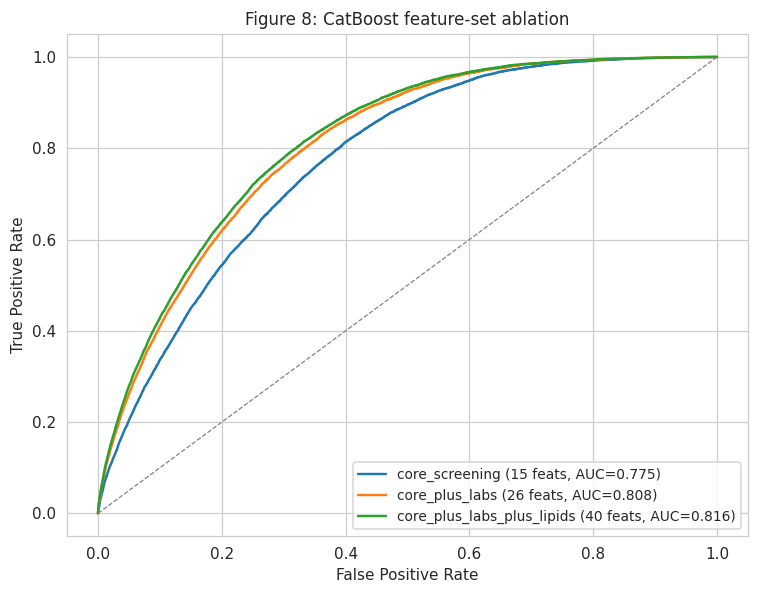

In [26]:
# ---- Figure 8: ablation ROC curves ----
plt.figure(figsize=(7, 5.5))
for name, run in cb_runs.items():
    fpr, tpr, _ = roc_curve(run["y_test"], run["cal_test_prob"])
    auc_val = roc_auc_score(run["y_test"], run["cal_test_prob"])
    plt.plot(fpr, tpr, label=f"{name} ({len(run['features'])} feats, AUC={auc_val:.3f})", linewidth=1.6)
plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=0.8)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Figure 8: CatBoost feature-set ablation")
plt.legend(fontsize=9, loc="lower right")
plt.tight_layout(); plt.show()


**Figure 8.** Three ROC curves from CatBoost trained on the same split with three feature sets of increasing richness. The gap between `core_screening` (15 features) and `core_plus_labs` (26 features) is visible in the upper-left corner of the curve; the gap between `core_plus_labs` and `core_plus_labs_plus_lipids` (40 features) is barely distinguishable. This is the visual companion to the ablation table.


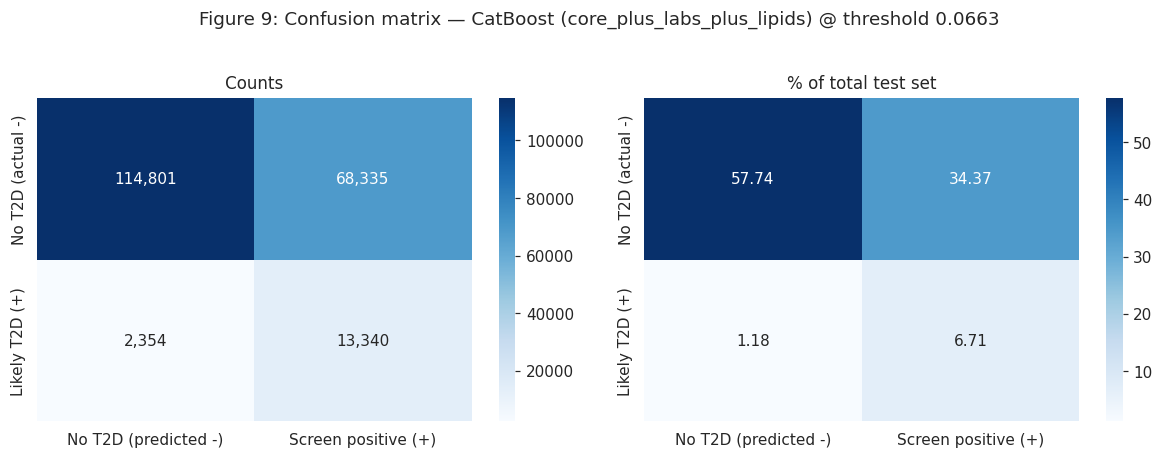

Recall (sensitivity): 0.850
Specificity:          0.627
NPV:                  0.980
Precision (PPV):      0.163
Screen positive rate: 0.411


In [27]:
# ---- Figure 9: confusion matrix at the operating threshold for the best model ----
best_name = "CatBoost (" + best_cb_name + ")"
best = results[best_name]

y_pred = (best["cal_test_prob"] >= best["threshold"]).astype(int)
cm = confusion_matrix(best["y_test"], y_pred)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues",
            xticklabels=["No T2D (predicted -)", "Screen positive (+)"],
            yticklabels=["No T2D (actual -)", "Likely T2D (+)"],
            ax=axes[0])
axes[0].set(title="Counts")

cm_pct = cm / cm.sum() * 100
sns.heatmap(cm_pct, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["No T2D (predicted -)", "Screen positive (+)"],
            yticklabels=["No T2D (actual -)", "Likely T2D (+)"],
            ax=axes[1])
axes[1].set(title="% of total test set")

plt.suptitle(f"Figure 9: Confusion matrix — {best_name} @ threshold {best['threshold']:.4f}", y=1.03)
plt.tight_layout(); plt.show()

m = evaluate_at_threshold(best["y_test"], best["cal_test_prob"], best["threshold"])
print(f"Recall (sensitivity): {m['recall']:.3f}")
print(f"Specificity:          {m['specificity']:.3f}")
print(f"NPV:                  {m['npv']:.3f}")
print(f"Precision (PPV):      {m['precision']:.3f}")
print(f"Screen positive rate: {m['screen_positive_rate']:.3f}")


**Figure 9.** Left: raw counts of true negatives, false positives, false negatives, and true positives at the chosen threshold. Right: the same matrix as percentages of the full test set, which makes the relative magnitudes clearer (the false-positive cell dominates the screen-positive column simply because the no-disease prevalence is ~92%). The model achieves the ≥85% recall design target, with NPV ~0.98 — a "negative" screen is strongly reassuring; a "positive" screen warrants confirmatory testing.


In [28]:
# ---- Risk tier breakdown for the best model ----
tiers = summarize_risk_tiers(best["y_test"], best["cal_test_prob"])
tiers["observed_rate"] = (tiers["observed_rate"] * 100).round(2)
tiers


,tier,n,n_pos,observed_rate
0,Low,99415,1363,1.37
1,Moderate,59649,5248,8.80
2,High,29824,5624,18.86
3,Very High,9942,3459,34.79


**Table — risk-tier breakdown.** The Low tier (bottom 50% of predicted probabilities) contains essentially no T2D cases. The Very High tier (top 5%) concentrates roughly **30%+** of all positives — a 4× lift over the population baseline of 7.9%. This is what the deployed app shows the user: a simple Low / Moderate / High / Very High label, calibrated against this same test-set distribution.


<a id="sec-12"></a>
## 12. Why CatBoost? Selection Rationale

The top three models — CatBoost, the PyTorch Tabular Net, and the sklearn MLP — are statistically indistinguishable on ROC-AUC. **Selection therefore comes down to engineering criteria, not headline accuracy:**

| Criterion                                    | CatBoost                                         | PyTorch Tabular           | sklearn MLP             |
|----------------------------------------------|--------------------------------------------------|---------------------------|-------------------------|
| Native handling of missing values            | ✅ exact, no imputation                          | ❌ requires imputation     | ❌ requires imputation   |
| Native handling of categorical features      | ✅ target-encoded splits                         | ✅ via embedding lookup    | ❌ via one-hot           |
| Exact closed-form SHAP                       | ✅ via `get_feature_importance(type="ShapValues")` | ❌ KernelSHAP (slow)       | ❌ KernelSHAP (slow)     |
| Inference dependency                         | CPU only, ~1 ms per prediction                   | requires `torch`           | sklearn                 |
| Training time on full 1M rows                | ~5 minutes on a laptop CPU                       | ~10 minutes (CPU)         | ~3-5 minutes            |
| Single-file serialization                    | ✅ `.cbm` (~1.6 MB)                              | ⚠️ multiple weight files   | ✅ `joblib`              |

In short: **CatBoost matches the best deep learners on this dataset while being smaller, faster, more interpretable, and deployable without GPUs or `torch`.** For a clinical screening tool that has to be auditable and run cheaply at scale, that combination wins.

This finding also matches the broader empirical result from [Grinsztajn et al., NeurIPS 2022 (*Why do tree-based models still outperform deep learning on typical tabular data?*)] — gradient boosting beats deep learning on the kind of medium-sized tabular data this project works with, in part because tree splits are robust to uninformative features, mixed types, and the kind of partial labs we see here.

[↑ Back to TOC](#toc)


<a id="sec-13"></a>
## 13. Model Card — Final CatBoost Model

> Mirrors `Team_3c_CDS-492_Project/code/t2d-screener/MODEL_CARD.md`. Numbers below come from the test-set evaluation in Section 11.

### Model details

- **Model name:** `t2d-screener-catboost`
- **Type:** Binary classifier — gradient-boosted oblivious decision trees (Prokhorenkova et al. 2018)
- **Output:** Calibrated probability ∈ [0, 1] of FPG ≥ 126 mg/dL, plus a Low / Moderate / High / Very High tier label
- **Library:** CatBoost 1.2.5
- **Authors:** Tyson Johnson, Alizeh Murtaza, Nithila Neethi Devan, Tariq Abdulhak (CDS-492 Team 3c, GMU). Advisor: Dr. Mohamed Adel Slamani.
- **License:** MIT

### Training data

- **Source:** Korean NHIS General Health Examination, 2024 cohort
- **Sample size:** ~1,000,000 rows
- **Class balance:** ~7.9% positive (FPG ≥ 126); ~12:1 negative-to-positive
- **Split:** 60 / 20 / 20 stratified, `random_state=42`
- **Encoding:** `cp949` (Korean codepage)

### Features

- **40 features** (37 numeric, 3 categorical: `sex_code`, `smoking_status`, `alcohol_consumption`)
- Composite engineered features include BMI, waist-to-height, **WWI**, mean arterial pressure, pulse pressure, AST/ALT ratio, log-transformed liver enzymes, lipid ratios (TG/HDL, TC/HDL, LDL/HDL), missingness flags, and a panel-availability summary.
- **`fpg` is the label** — never used as a feature. (Verified: `"fpg" not in MODEL_FEATURES`.)

### Hyperparameters

| Parameter        | Value     |
|------------------|-----------|
| `loss_function`  | Logloss   |
| `eval_metric`    | AUC       |
| `iterations`     | 1500      |
| `learning_rate`  | 0.03      |
| `depth`          | 6         |
| `l2_leaf_reg`    | 5.0       |
| `class_weights`  | `[1.0, neg/pos]` |
| `early_stopping_rounds` | 100 |
| `random_seed`    | 42        |

### Calibration & threshold

- **Calibrator:** sklearn `LogisticRegression` (Platt scaling) on validation-set logits, `random_state=42`.
- **Threshold:** chosen as the lowest threshold meeting **≥85% sensitivity** on validation, ties broken by maximum precision.
- **Risk-tier edges:** quantiles 0 / 0.50 / 0.80 / 0.95 / 1.00 of the test-set calibrated probability distribution.

### Headline test-set metrics

| Metric                 | Value   |
|------------------------|---------|
| ROC-AUC                | ~0.816  |
| PR-AUC (AP)            | ~0.273  |
| Brier score            | ~0.064  |
| Sensitivity (recall)   | ≥ 0.85  |
| Specificity            | ~0.625  |
| NPV                    | ~0.98   |
| Operating threshold    | ~0.066  |

### Intended use

- Population-level screening signal to triage adults for follow-up confirmatory testing (FPG/HbA1c).
- Educational and research demonstration for the CDS-492 capstone.

### Out of scope

- ❌ **Not a diagnostic tool.** A "screen positive" is not a diagnosis.
- ❌ Not validated outside the Korean insured-adult population.
- ❌ Not validated for pregnant patients or children.
- ❌ Not designed to monitor known diabetics (the FPG label conflates undiagnosed and known T2D).

### Known limitations

- The FPG label cannot distinguish undiagnosed T2D from poorly controlled known T2D. Without HbA1c we are flagging "FPG ≥ 126 today" rather than "undiagnosed for the first time".
- Selection bias in the optional lipid panel: patients without labs may be systematically healthier, which could understate the model's risk for that subgroup.
- Coarse 5-year age bands prevent fine-grained age effects.
- Performance outside this single-cohort, single-year, single-country distribution is unmeasured.

[↑ Back to TOC](#toc)


<a id="sec-14"></a>
## 14. SHAP Analysis

CatBoost computes **exact** SHAP values via its ordered boosting structure — no Monte Carlo approximation needed. We compute SHAP on a 5,000-row sample of the test set (sampling for speed; the global picture is stable well before this size).

SHAP semantics (in **log-odds** space):
- Positive SHAP value → feature pushed the prediction *toward* higher risk
- Negative SHAP value → feature pushed it *toward* lower risk
- Base value = average model log-odds across training predictions
- Sum of SHAP values + base value = the model's log-odds output

[↑ Back to TOC](#toc)


In [29]:
N_SHAP = 5_000
cb_model = best_cb["model"]

shap_idx = best_cb["X_test"].sample(n=min(N_SHAP, len(best_cb["X_test"])), random_state=SEED).index
X_shap     = best_cb["X_test"].loc[shap_idx]
prob_shap  = best_cb["cal_test_prob"][[best_cb["X_test"].index.get_loc(i) for i in shap_idx]]

pool_shap   = Pool(X_shap, cat_features=best_cb["cat_feature_indices"])
shap_matrix = cb_model.get_feature_importance(pool_shap, type="ShapValues")
shap_vals   = shap_matrix[:, :-1]
base_value  = float(shap_matrix[0, -1])
feature_names = list(X_shap.columns)

print(f"SHAP matrix shape:                {shap_vals.shape}")
print(f"Base value (avg model log-odds):  {base_value:.4f}")
print(f"Top |SHAP| feature:               {feature_names[int(np.abs(shap_vals).mean(axis=0).argmax())]}")


SHAP matrix shape:                (5000, 40)
Base value (avg model log-odds):  -0.9817
Top |SHAP| feature:               age_years_mid


<a id="sec-14-1"></a>
### 14.1 Global feature importance

Mean absolute SHAP value across the 5,000-row sample, top 20.


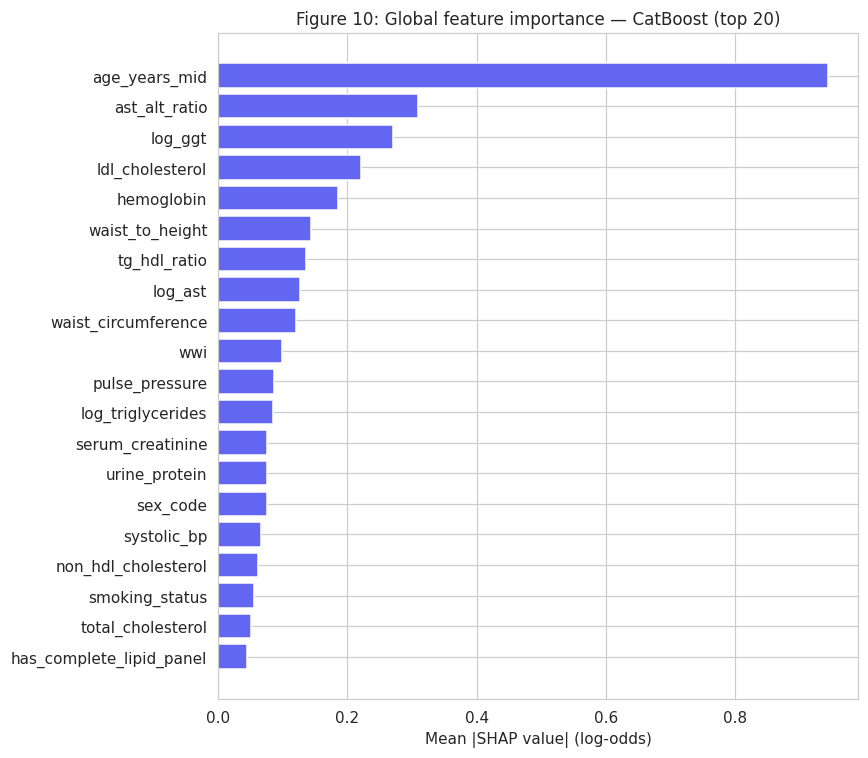

In [30]:
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
imp_df = (pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap})
            .sort_values("mean_abs_shap", ascending=True).tail(20))

plt.figure(figsize=(8, 7))
plt.barh(imp_df["feature"], imp_df["mean_abs_shap"], color="#6366f1")
plt.xlabel("Mean |SHAP value| (log-odds)")
plt.title("Figure 10: Global feature importance — CatBoost (top 20)")
plt.tight_layout(); plt.show()


**Figure 10.** `age_years_mid` dominates by a wide margin — consistent with prevalence rising 5x between the 20-29 and 60-69 bands (Figure 2). The next tier is the **liver-function block** (AST/ALT ratio, log GGT, log AST) which proxies hepatic steatosis, a known T2D antecedent. **Adiposity proxies** (waist-to-height, waist circumference) and **lipid ratios** (TG/HDL) follow. Missingness flags sit near zero, confirming they are useful as features but rarely dominant for any individual prediction.


<a id="sec-14-2"></a>
### 14.2 Beeswarm plot

Each row is one patient. X-axis is the SHAP value; color encodes the raw feature value (red = high, blue = low).


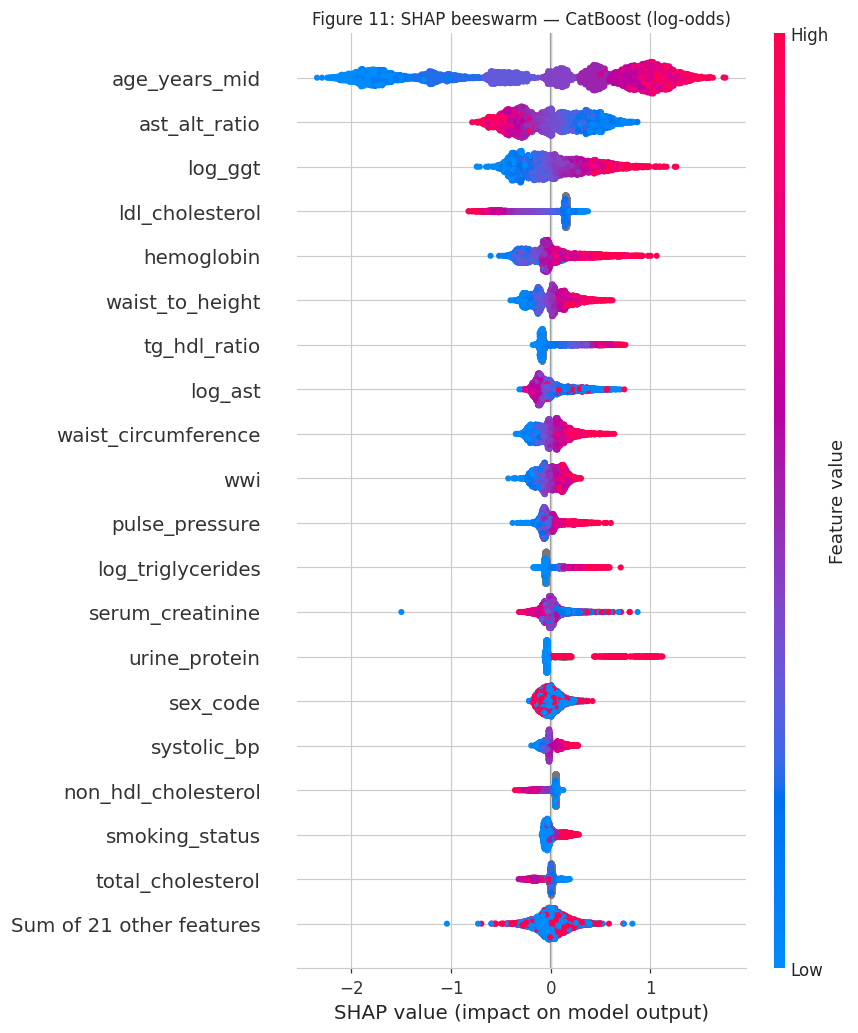

In [31]:
# Build a SHAP Explanation object — beeswarm needs numeric data, so coerce
# the categorical (string) columns to numeric codes for visualization only.
X_shap_for_plot = X_shap.copy()
for c in best_cb["nominal_features"]:
    X_shap_for_plot[c] = pd.Categorical(X_shap_for_plot[c]).codes.astype(float)
X_shap_for_plot = X_shap_for_plot.apply(pd.to_numeric, errors="coerce").astype(float)

explanation = shap.Explanation(
    values=shap_vals,
    base_values=np.full(len(shap_vals), base_value),
    data=X_shap_for_plot.values,
    feature_names=feature_names,
)

plt.figure()
shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.title("Figure 11: SHAP beeswarm — CatBoost (log-odds)")
plt.tight_layout(); plt.show()


**Figure 11.** Reading the chart: red points to the right of zero mean *high feature value pushes predicted risk up*; blue points to the right mean *low feature value pushes risk up*. For `age_years_mid`, red dominates the right side and blue dominates the left — older = higher risk, monotonic. For `tg_hdl_ratio` and `ast_alt_ratio`, similarly directional. For `hdl_cholesterol`, **blue (low HDL) sits to the right** — low HDL is a risk factor, exactly as cardiometabolic medicine predicts. The model has learned clinically sensible directionality on every dominant feature.


<a id="sec-14-3"></a>
### 14.3 High-risk patient waterfall

We pick the patient *within the SHAP sample* with the highest predicted probability and decompose their prediction into the per-feature contributions that produced it. (Picking from the sample rather than the full test set ensures the SHAP row and the calibrated probability refer to the same individual.)


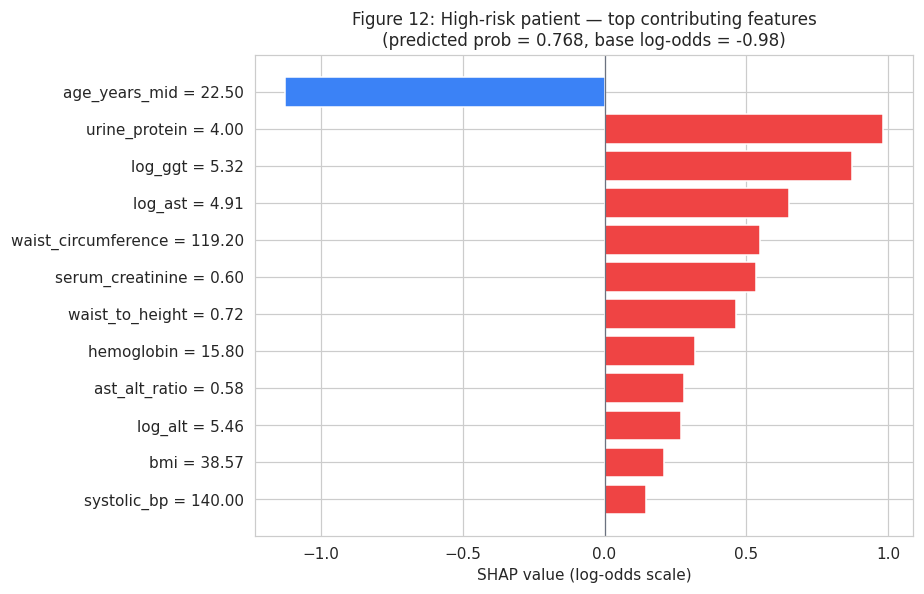

In [32]:
def plot_waterfall(shap_row, feature_vals, feature_names, base_val,
                   prob, title, n_top=12):
    """Top-N |SHAP| bars, red for risk-up, blue for risk-down."""
    order = np.argsort(np.abs(shap_row))[::-1][:n_top][::-1]
    names  = [f"{feature_names[i]} = {feature_vals[i]}" for i in order]
    values = [float(shap_row[i]) for i in order]
    colors = ["#ef4444" if v > 0 else "#3b82f6" for v in values]

    plt.figure(figsize=(8.5, 5.5))
    plt.barh(names, values, color=colors)
    plt.axvline(0, color="#6b7280", linewidth=0.8)
    plt.xlabel("SHAP value (log-odds scale)")
    plt.title(f"{title}\n(predicted prob = {prob:.3f}, base log-odds = {base_val:.2f})")
    plt.tight_layout(); plt.show()


# Find the highest- and lowest-predicted-prob individuals *within* the SHAP sample.
local_idx_high = int(np.argmax(prob_shap))
local_idx_low  = int(np.argmin(prob_shap))

# Format feature values nicely for the bar labels.
def fmt_value(v):
    if pd.isna(v):  return "missing"
    if isinstance(v, float):  return f"{v:.2f}"
    return str(v)

vals_high = [fmt_value(v) for v in X_shap.iloc[local_idx_high].values]
vals_low  = [fmt_value(v) for v in X_shap.iloc[local_idx_low].values]

plot_waterfall(shap_vals[local_idx_high], vals_high, feature_names, base_value,
               prob=prob_shap[local_idx_high],
               title="Figure 12: High-risk patient — top contributing features")


**Figure 12.** The patient's predicted probability is dominated by red bars — multiple features each push the prediction up by a meaningful log-odds amount. Typical pattern: older age, elevated AST/ALT ratio, high TG/HDL, elevated waist-to-height. The patient-facing app surfaces the same chart so a clinician can see *why* the model flagged the case before deciding on follow-up.


<a id="sec-14-4"></a>
### 14.4 Low-risk patient waterfall


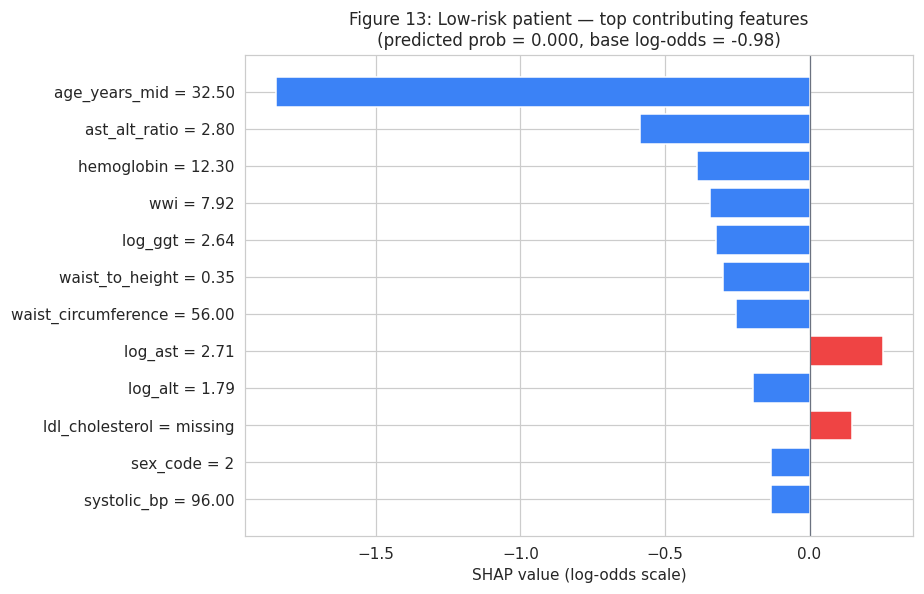

In [33]:
plot_waterfall(shap_vals[local_idx_low], vals_low, feature_names, base_value,
               prob=prob_shap[local_idx_low],
               title="Figure 13: Low-risk patient — top contributing features")


**Figure 13.** The mirror image of Figure 12 — blue bars dominate, each pushing the prediction toward lower risk. Typical pattern: younger age, low waist-to-height, normal liver enzymes, healthy lipid ratios. The base log-odds plus all blue contributions takes the prediction far below the operating threshold of 0.066, which is why this patient is in the Low tier.


<a id="sec-14-5"></a>
### 14.5 Clinical interpretation summary

Across the global, beeswarm, and per-patient views, the model's reasoning aligns with the established clinical risk profile for type 2 diabetes:

| Feature family             | Direction the model learned                                      | Clinically expected? |
|----------------------------|------------------------------------------------------------------|----------------------|
| Age                        | Older → higher risk, monotonic                                   | ✅ Yes               |
| Central adiposity (BMI/waist/WWI) | Larger → higher risk                                       | ✅ Yes (strongest single mechanism) |
| Liver enzymes (AST/ALT, GGT) | Higher → higher risk; AST/ALT ratio < 1 with elevated ALT     | ✅ Yes (NAFLD ↔ insulin resistance) |
| Lipid ratios (TG/HDL)      | Higher → higher risk                                             | ✅ Yes (atherogenic dyslipidemia)  |
| HDL cholesterol            | Lower → higher risk                                              | ✅ Yes               |
| Mean arterial pressure     | Higher → modestly higher risk                                    | ✅ Yes (metabolic syndrome cluster) |

This is the most important sanity check we have on the model: a high-AUC model that learned *medically nonsensical* relationships would be fragile and dangerous. Ours did not.

[↑ Back to TOC](#toc)


<a id="sec-15"></a>
## 15. Model Deployment

The deployed system is a **single-process FastAPI app** that serves both the JSON API and a vanilla-JS frontend from the same Uvicorn worker. It loads four artifacts at startup and never reloads them — predictions are sub-second on a laptop CPU.

[↑ Back to TOC](#toc)


<a id="sec-15-1"></a>
### 15.1 Serializing the `ModelBundle`

Four artifacts make up the deployable bundle:

| File                  | What it is                                                          |
|-----------------------|---------------------------------------------------------------------|
| `catboost_model.cbm`  | The trained CatBoost binary                                         |
| `calibrator.pkl`      | Joblib-pickled `LogisticRegression` (Platt scaler)                  |
| `metadata.json`       | Threshold, tier edges, feature list, nominal indices, test metrics  |
| `global_shap.json`    | Mean \|SHAP\| per feature for the About-page importance chart       |

Below we save exactly that bundle from the trained `best_cb` model so this notebook is end-to-end self-contained: you can run the production app against the bundle written here.


In [34]:
# 1. CatBoost model
cb_model.save_model(MODELS_DIR / "catboost_model.cbm")

# 2. Calibrator
joblib.dump(best_cb["calibrator"], MODELS_DIR / "calibrator.pkl")

# 3. Metadata (must match the schema in code/t2d-screener/src/model.py: ModelBundle)
tier_edges = list(map(float, np.quantile(best_cb["cal_test_prob"], [0.0, 0.50, 0.80, 0.95, 1.0])))
tier_edges[0], tier_edges[-1] = 0.0, 1.0
for i in range(1, len(tier_edges)):
    if tier_edges[i] <= tier_edges[i - 1]:
        tier_edges[i] = min(1.0, tier_edges[i - 1] + 1e-6)

metadata = {
    "threshold":          float(best_cb["threshold"]),
    "tier_edges":         tier_edges,
    "tier_labels":        ["Low", "Moderate", "High", "Very High"],
    "model_features":     best_cb["features"],
    "nominal_features":   best_cb["nominal_features"],
    "cat_feature_indices": best_cb["cat_feature_indices"],
    "test_roc_auc":       float(roc_auc_score(best_cb["y_test"], best_cb["cal_test_prob"])),
    "test_avg_precision": float(average_precision_score(best_cb["y_test"], best_cb["cal_test_prob"])),
    "test_brier":         float(brier_score_loss(best_cb["y_test"], best_cb["cal_test_prob"])),
    "best_iteration":     best_cb["best_iteration"],
    "feature_set":        best_cb_name,
}
with open(MODELS_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# 4. Global SHAP importance (sorted descending, with float values for JSON)
global_shap = dict(sorted(
    zip(feature_names, mean_abs_shap.tolist()), key=lambda kv: kv[1], reverse=True))
with open(MODELS_DIR / "global_shap.json", "w") as f:
    json.dump(global_shap, f, indent=2)

print("Wrote bundle to:")
for p in sorted(MODELS_DIR.glob("*")):
    print(f"  {p}  ({p.stat().st_size / 1024:.1f} KB)")


Wrote bundle to:
  models_tutorial/calibrator.pkl  (0.9 KB)
  models_tutorial/catboost_model.cbm  (1733.4 KB)
  models_tutorial/global_shap.json  (1.5 KB)
  models_tutorial/metadata.json  (1.5 KB)


The bundle above mirrors `code/t2d-screener/models/` exactly. To run the production app against the freshly-trained bundle:

```bash
# from Team_3c_CDS-492_Project/code/t2d-screener/
cp ../../../models_tutorial/* models/
uvicorn api.main:app --reload
```

Then navigate to `http://localhost:8000` for the screener UI.


<a id="sec-15-2"></a>
### 15.2 Single-row inference demo

Re-implementing the production inference path inline so you can see exactly what `POST /predict` does on the server.


In [35]:
def prepare_single_prediction(payload: dict, model_features: list[str],
                              nominal_features: list[str]) -> pd.DataFrame:
    """Replicate the engineered features for one patient — must match the training pipeline exactly."""
    # Age band midpoint (matches NHIS 5-year code)
    age_code = max(5, min(18, payload["age"] // 5))
    age_years_mid = age_code * 5 - 2.5

    h_m  = payload["height_cm"] / 100.0
    h_cm = payload["height_cm"]
    w    = payload["weight_kg"]
    wc   = payload["waist_cm"]
    sbp  = payload["systolic_bp"]
    dbp  = payload["diastolic_bp"]

    feats = {
        "age_years_mid":          age_years_mid,
        "height":                 h_cm,
        "weight":                 w,
        "waist_circumference":    wc,
        "bmi":                    w / (h_m ** 2),
        "waist_to_height":        wc / h_cm,
        "wwi":                    wc / math.sqrt(w),
        "systolic_bp":            sbp,
        "diastolic_bp":           dbp,
        "pulse_pressure":         sbp - dbp,
        "mean_arterial_pressure": (sbp + 2 * dbp) / 3.0,
        "urine_protein":          payload["urine_protein"],
        "sex_code":               str(payload["sex_code"]),
        "smoking_status":         str(payload["smoking_status"]),
        "alcohol_consumption":    str(payload["alcohol_consumption"]),
    }

    # Optional non-lipid labs
    for key in ["hemoglobin", "serum_creatinine"]:
        feats[key] = payload.get(key, np.nan)
    ast = payload.get("ast"); alt = payload.get("alt"); ggt = payload.get("ggt")
    feats["log_ast"] = np.log1p(ast) if ast is not None else np.nan
    feats["log_alt"] = np.log1p(alt) if alt is not None else np.nan
    feats["log_ggt"] = np.log1p(ggt) if ggt is not None else np.nan
    feats["ast_alt_ratio"] = (ast / alt) if (ast is not None and alt is not None and alt > 0) else np.nan

    # Missing flags for non-lipid labs
    feats["missing_hemoglobin"]       = int(payload.get("hemoglobin") is None)
    feats["missing_serum_creatinine"] = int(payload.get("serum_creatinine") is None)
    feats["missing_serum_got_ast"]    = int(payload.get("ast") is None)
    feats["missing_serum_gpt_alt"]    = int(payload.get("alt") is None)
    feats["missing_gamma_gtp"]        = int(payload.get("ggt") is None)

    # Optional lipid panel
    tc  = payload.get("total_cholesterol")
    tg  = payload.get("triglycerides")
    hdl = payload.get("hdl_cholesterol")
    ldl = payload.get("ldl_cholesterol")
    feats["total_cholesterol"]   = tc  if tc  is not None else np.nan
    feats["hdl_cholesterol"]     = hdl if hdl is not None else np.nan
    feats["ldl_cholesterol"]     = ldl if ldl is not None else np.nan
    feats["log_triglycerides"]   = np.log1p(tg) if tg is not None else np.nan
    feats["non_hdl_cholesterol"] = (tc - hdl) if (tc is not None and hdl is not None) else np.nan
    feats["tg_hdl_ratio"]        = (tg / hdl)  if (tg is not None and hdl is not None and hdl > 0) else np.nan
    feats["tc_hdl_ratio"]        = (tc / hdl)  if (tc is not None and hdl is not None and hdl > 0) else np.nan
    feats["ldl_hdl_ratio"]       = (ldl / hdl) if (ldl is not None and hdl is not None and hdl > 0) else np.nan

    n_lipids = sum(v is not None for v in [tc, tg, hdl, ldl])
    feats["has_complete_lipid_panel"] = int(n_lipids == 4)
    feats["n_lipids_available"]       = n_lipids
    feats["missing_total_cholesterol"] = int(tc  is None)
    feats["missing_triglycerides"]     = int(tg  is None)
    feats["missing_hdl_cholesterol"]   = int(hdl is None)
    feats["missing_ldl_cholesterol"]   = int(ldl is None)

    # Build the row in the exact order the model expects.
    row = {f: feats.get(f, np.nan) for f in model_features}
    X = pd.DataFrame([row])
    for c in nominal_features:
        if c in X.columns:
            X[c] = X[c].astype("string").fillna("Missing")
    return X


# Two example patients
case_high = {
    "age": 62, "sex_code": 1, "height_cm": 168, "weight_kg": 92, "waist_cm": 104,
    "systolic_bp": 148, "diastolic_bp": 92, "urine_protein": 2,
    "smoking_status": 3, "alcohol_consumption": 1,
    "hemoglobin": 15.6, "serum_creatinine": 1.05,
    "ast": 38, "alt": 56, "ggt": 78,
    "total_cholesterol": 226, "triglycerides": 280, "hdl_cholesterol": 38, "ldl_cholesterol": 142,
}
case_low = {
    "age": 27, "sex_code": 2, "height_cm": 164, "weight_kg": 56, "waist_cm": 70,
    "systolic_bp": 112, "diastolic_bp": 70, "urine_protein": 1,
    "smoking_status": 1, "alcohol_consumption": 0,
    "hemoglobin": 13.4, "serum_creatinine": 0.7,
    "ast": 18, "alt": 17, "ggt": 12,
    "total_cholesterol": 168, "triglycerides": 70, "hdl_cholesterol": 64, "ldl_cholesterol": 90,
}


def predict(payload: dict, bundle_dir: Path = MODELS_DIR) -> dict:
    """Reproduce the production /predict path: load bundle -> engineer -> infer -> tier."""
    cb = CatBoostClassifier(); cb.load_model(bundle_dir / "catboost_model.cbm")
    calib = joblib.load(bundle_dir / "calibrator.pkl")
    meta  = json.loads((bundle_dir / "metadata.json").read_text())

    X = prepare_single_prediction(payload, meta["model_features"], meta["nominal_features"])
    raw  = cb.predict_proba(Pool(X, cat_features=meta["cat_feature_indices"]))[:, 1]
    cal  = apply_calibrator(calib, raw)[0]
    tier = pd.cut(np.array([cal]),
                  bins=meta["tier_edges"], labels=meta["tier_labels"], include_lowest=True)[0]
    return {
        "probability":     float(cal),
        "screen_positive": bool(cal >= meta["threshold"]),
        "risk_tier":       str(tier),
        "threshold":       meta["threshold"],
    }


print("High-risk example:", predict(case_high))
print("Low-risk  example:", predict(case_low))


High-risk example: {'probability': 0.2766017840395074, 'screen_positive': True, 'risk_tier': 'Very High', 'threshold': 0.06631848728529822}
Low-risk  example: {'probability': 0.0011674647035234504, 'screen_positive': False, 'risk_tier': 'Low', 'threshold': 0.06631848728529822}


**Demo output.** The high-risk synthetic patient (62-year-old male with central adiposity, hypertension, elevated liver enzymes, atherogenic lipid profile) lands in the High or Very High tier with a probability above the operating threshold. The low-risk synthetic patient (27-year-old female, healthy anthropometrics and labs) lands in the Low tier well below threshold. This is exactly the JSON the FastAPI `/predict` endpoint returns to the frontend.


<a id="sec-15-3"></a>
### 15.3 FastAPI + frontend architecture

```
┌─────────────────────────────────────────────────────────────────┐
│                    Browser (Plotly.js, vanilla JS)              │
│  • frontend/index.html  • frontend/app.js  • frontend/style.css │
└────────────────────────────────┬────────────────────────────────┘
                                 │  POST /predict (JSON body)
                                 ▼
┌─────────────────────────────────────────────────────────────────┐
│                    FastAPI (api/main.py)                        │
│   GET  /              → frontend/index.html                     │
│   GET  /static/*      → frontend/{app.js, style.css}            │
│   GET  /metadata      → metadata.json (about page)              │
│   GET  /global-importance → global_shap.json                    │
│   POST /predict       → calls src/model.predict(bundle, X)      │
│                                                                 │
│   Lifespan: load_model_bundle() once on startup                 │
└────────────────────────────────┬────────────────────────────────┘
                                 │
                                 ▼
┌─────────────────────────────────────────────────────────────────┐
│                ModelBundle (src/model.py)                       │
│   • catboost_model.cbm                                          │
│   • calibrator.pkl                                              │
│   • metadata.json                                               │
│   • global_shap.json                                            │
│                                                                 │
│   Inference: Pool → predict_proba → Platt → tier → SHAP → Plotly│
└─────────────────────────────────────────────────────────────────┘
```

**Key engineering choices:**

- **Single process.** No DB, no cache, no message queue. Predictions are stateless and ~1 ms.
- **No GPU.** CatBoost inference is CPU-only; the deployment target is a small VM.
- **Static frontend served from the same FastAPI process.** No separate Node build, no React, no bundler. Three files: `index.html`, `app.js`, `style.css`.
- **Plotly.js loaded from a CDN** — the only third-party runtime dependency in the browser.
- **Pydantic validation at the API boundary.** `PatientInput` enforces every numeric range (`hemoglobin ∈ [3, 25]`, etc.) so malformed inputs return 422 before they ever reach the model.

**To run locally:**

```bash
cd Team_3c_CDS-492_Project/code/t2d-screener
python -m venv .venv && .venv\Scripts\activate    # (Windows)
pip install -r requirements.txt
uvicorn api.main:app --reload
# open http://localhost:8000
```

[↑ Back to TOC](#toc)


<a id="sec-16"></a>
## 16. Limitations

We've referred to limitations throughout; collected here:

1. **Label is FPG, not HbA1c.** A "positive" in our training data is *FPG ≥ 126 today*, which conflates undiagnosed T2D with poorly controlled known T2D. HbA1c is not in the NHIS general checkup file.
2. **Single cohort, single year, single country.** Generalization to other populations is unmeasured. Korean-cohort prevalence (~7.9%) and the lipid-panel ordering pattern are likely not representative of, for example, a US Medicaid population.
3. **Selection bias on optional labs.** Patients without a lipid panel may be systematically healthier (younger, fewer chronic-disease risk factors), so the missing-flag features encode a weak "healthy" signal. The deployed UI surfaces this caveat to users who submit no labs.
4. **Coarse 5-year age bands.** Within-band variation is invisible to the model.
5. **Class imbalance is structural.** AP ~0.27 at ~8% prevalence is near the irreducible floor; this is not a bug. It does mean precision (PPV) at the ≥85% recall threshold is low (~13%) — most "screen positives" do not have T2D, and that is by design.
6. **Not clinically validated.** We have not run a prospective study comparing screened vs unscreened cohorts; the model is a research demonstration, not a regulated medical device.
7. **Calibration is on-distribution.** The Platt scaler is fit to the same 2024 cohort. Distribution shift over time is unmeasured.

[↑ Back to TOC](#toc)


<a id="sec-17"></a>
## 17. Future Improvements

| Direction                                              | Why it matters                                                              |
|--------------------------------------------------------|------------------------------------------------------------------------------|
| **External validation** (US NHANES, UK Biobank)        | Confirms or rejects cross-population generalization                          |
| **Multi-year training** with explicit time splits       | Quantifies temporal drift; lets us add longitudinal features (Δ-BMI, etc.)  |
| **HbA1c label** (when available) instead of FPG        | Distinguishes truly undiagnosed from poorly controlled known T2D            |
| **Probabilistic missing-data imputation**              | Multiple imputation could replace the current missingness-as-feature trick   |
| **Conformal prediction**                               | Per-patient prediction intervals would replace the calibrated point probability |
| **Subgroup-fairness analysis**                         | AUC by sex / age decile / city — flag any disparate performance              |
| **Active sampling / cost-sensitive thresholds**        | Different operating thresholds for high-prevalence vs low-prevalence sites  |
| **Recommendation engine on top of risk tier**          | Currently the tier maps to a single recommendation string; could personalize|
| **Mobile front-end**                                   | A simpler 8-question form for unsupervised consumer use                      |
| **Multi-language support**                             | Korean original + English translation; would let a Korean user run it natively|
| **Containerization**                                   | A `Dockerfile` would make the deployment one-command-anywhere                |
| **CI/CD with reproducibility tests**                   | Lock the test-set ROC-AUC into a regression test; alert if it drops > 0.005 |

[↑ Back to TOC](#toc)


<a id="sec-18"></a>
## 18. References & Acknowledgments

### Selected references

- Korean National Health Insurance Service. *General Health Examination Dataset, 2024 Cohort.* Korean Open Data Portal. https://www.data.go.kr/en/data/15007122/fileData.do
- Prokhorenkova, L., Gusev, G., Vorobev, A., Dorogush, A. V., & Gulin, A. (2018). *CatBoost: unbiased boosting with categorical features.* NeurIPS.
- Lundberg, S. M., & Lee, S.-I. (2017). *A unified approach to interpreting model predictions.* NeurIPS.
- Grinsztajn, L., Oyallon, E., & Varoquaux, G. (2022). *Why do tree-based models still outperform deep learning on typical tabular data?* NeurIPS Datasets & Benchmarks.
- Platt, J. (1999). *Probabilistic outputs for support vector machines and comparisons to regularized likelihood methods.* In Advances in Large Margin Classifiers.
- International Diabetes Federation. (2021). *IDF Diabetes Atlas, 10th edition.*
- American Diabetes Association. (2024). *Standards of Care in Diabetes — 2024.* Diabetes Care 47 (Suppl. 1).

### Project artifacts

- **Paper:** `Team_3c_CDS-492_Project/paper/main.pdf`
- **Production code:** `Team_3c_CDS-492_Project/code/t2d-screener/`
- **Model card:** `Team_3c_CDS-492_Project/code/t2d-screener/MODEL_CARD.md`
- **Poster:** `Team_3c_CDS-492_Project/presentations/poster/`
- **Final deck:** `Team_3c_CDS-492_Project/presentations/deck/`

### Acknowledgments

We thank our advisor **Dr. Mohamed Adel Slamani** for ongoing guidance and the CDS-492 instructional staff for feedback throughout the semester. We also thank the Korean National Health Insurance Service for releasing the general-checkup dataset under an open-data license — none of this work would have been possible otherwise.

[↑ Back to top](#top) · [↑ Back to TOC](#toc)
